<a href="https://colab.research.google.com/github/DrishtiNigam1928/CUSTOMER_CHURN/blob/main/notebooks/main_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import files
uploaded = files.upload()

Saving train_dataset.csv to train_dataset (1).csv


In [3]:
import os
print(os.listdir())

['.config', 'train_dataset.csv', 'train_dataset (1).csv', 'sample_data']


In [4]:
import pandas as pd
import numpy as np

# FILENAME = "E Commerce Dataset.xlsx"   # match this exactly to what os.listdir() showed
# df = pd.read_excel(FILENAME, sheet_name="E Comm")

# FILENAME = "test_dataset.csv"
FILENAME = "train_dataset.csv"
df = pd.read_csv(FILENAME)

print("Shape:", df.shape)
df.head()

Shape: (4504, 20)


,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
0,51783,0,3.0,Phone,3,13.0,E wallet,Male,NaN,3,Mobile,4,Single,1,0,14.0,0.0,1.0,2.0,129.83
1,53527,1,1.0,Mobile Phone,3,30.0,Debit Card,Female,3.0,5,Fashion,5,Divorced,3,0,14.0,1.0,4.0,11.0,198.36
2,51188,1,0.0,Phone,2,24.0,UPI,Male,NaN,1,Mobile,5,Married,1,0,17.0,1.0,1.0,0.0,129.56
3,50275,0,NaN,Phone,1,6.0,Debit Card,Male,3.0,4,Mobile,5,Divorced,2,0,12.0,0.0,3.0,2.0,122.18
4,53337,0,27.0,Mobile Phone,3,15.0,E wallet,Male,4.0,4,Grocery,2,Divorced,7,0,15.0,1.0,NaN,3.0,243.36


In [5]:

num_rows = 0
for _ in df.itertuples():
    num_rows += 1
print("Number of rows/observations:", num_rows)

# 2. Number of columns/features (without .shape)
column_list = []
for col in df:
    column_list.append(col)
num_cols = len(column_list)
print("Number of columns/features:", num_cols)
print("Column names:", column_list)

Number of rows/observations: 4504
Number of columns/features: 20
Column names: ['CustomerID', 'Churn', 'Tenure', 'PreferredLoginDevice', 'CityTier', 'WarehouseToHome', 'PreferredPaymentMode', 'Gender', 'HourSpendOnApp', 'NumberOfDeviceRegistered', 'PreferedOrderCat', 'SatisfactionScore', 'MaritalStatus', 'NumberOfAddress', 'Complain', 'OrderAmountHikeFromlastYear', 'CouponUsed', 'OrderCount', 'DaySinceLastOrder', 'CashbackAmount']


In [6]:
#A2: Input features & Target variable
target_col = "Churn"
id_col = "CustomerID"

input_features = [c for c in df.columns if c not in [target_col, id_col]]

print("Target variable:", target_col)
print("Number of input features:", len(input_features))
print("Input features:", input_features)

Target variable: Churn
Number of input features: 18
Input features: ['Tenure', 'PreferredLoginDevice', 'CityTier', 'WarehouseToHome', 'PreferredPaymentMode', 'Gender', 'HourSpendOnApp', 'NumberOfDeviceRegistered', 'PreferedOrderCat', 'SatisfactionScore', 'MaritalStatus', 'NumberOfAddress', 'Complain', 'OrderAmountHikeFromlastYear', 'CouponUsed', 'OrderCount', 'DaySinceLastOrder', 'CashbackAmount']


In [7]:
#  A2: Numerical vs Categorical variables -
numerical_vars = df[input_features].select_dtypes(include=np.number).columns.tolist()
categorical_vars = df[input_features].select_dtypes(exclude=np.number).columns.tolist()

print("Numerical variables (", len(numerical_vars), "):", numerical_vars)
print()
print("Categorical variables (", len(categorical_vars), "):", categorical_vars)


Numerical variables ( 13 ): ['Tenure', 'CityTier', 'WarehouseToHome', 'HourSpendOnApp', 'NumberOfDeviceRegistered', 'SatisfactionScore', 'NumberOfAddress', 'Complain', 'OrderAmountHikeFromlastYear', 'CouponUsed', 'OrderCount', 'DaySinceLastOrder', 'CashbackAmount']

Categorical variables ( 5 ): ['PreferredLoginDevice', 'PreferredPaymentMode', 'Gender', 'PreferedOrderCat', 'MaritalStatus']


In [8]:
# A2: Source of dataset -
print("Source: Kaggle - Ecommerce Customer Churn Analysis and Prediction")
print("URL: https://www.kaggle.com/datasets/ankitverma2010/ecommerce-customer-churn-analysis-and-prediction")

Source: Kaggle - Ecommerce Customer Churn Analysis and Prediction
URL: https://www.kaggle.com/datasets/ankitverma2010/ecommerce-customer-churn-analysis-and-prediction


In [9]:
df.describe()

,CustomerID,Churn,Tenure,CityTier,WarehouseToHome,HourSpendOnApp,NumberOfDeviceRegistered,SatisfactionScore,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
count,4504.000000,4504.000000,4286.000000,4504.000000,4298.000000,4306.000000,4504.000000,4504.000000,4504.000000,4504.000000,4292.000000,4299.000000,4302.000000,4267.000000,4504.000000
mean,52812.063277,0.167185,10.248250,1.660524,15.677059,2.924059,3.678508,3.071492,4.199156,0.279973,15.703868,1.742731,3.008601,4.536208,177.036328
std,1622.033266,0.373182,8.579722,0.917656,8.573136,0.722650,1.015807,1.386379,2.575977,0.449036,3.677282,1.869115,2.956583,3.674367,49.245458
min,50002.000000,0.000000,0.000000,1.000000,5.000000,0.000000,1.000000,1.000000,1.000000,0.000000,11.000000,0.000000,1.000000,0.000000,0.000000
25%,51416.500000,0.000000,2.000000,1.000000,9.000000,2.000000,3.000000,2.000000,2.000000,0.000000,13.000000,1.000000,1.000000,2.000000,145.800000
50%,52788.500000,0.000000,9.000000,1.000000,14.000000,3.000000,4.000000,3.000000,3.000000,0.000000,15.000000,1.000000,2.000000,3.000000,163.230000
75%,54224.250000,0.000000,16.000000,3.000000,20.000000,3.000000,4.000000,4.000000,6.000000,1.000000,18.000000,2.000000,3.000000,7.000000,196.190000
max,55629.000000,1.000000,61.000000,3.000000,127.000000,5.000000,6.000000,5.000000,21.000000,1.000000,26.000000,15.000000,16.000000,46.000000,324.990000


In [10]:
#  All Numerical features
features_to_test = [
    'Tenure',
    'WarehouseToHome',
    'HourSpendOnApp',
    'NumberOfDeviceRegistered',
    'NumberOfAddress',
    'OrderCount',
    'CouponUsed',
    'DaySinceLastOrder',
    'CityTier',
    'SatisfactionScore',
    'OrderAmountHikeFromlastYear',
    'Complain',
    'CashbackAmount'
]

In [11]:
def execute_task_B1(dataframe):
  print("Task B1: Initial Data Exploration and Structure Inspection\n")

  display(df.head(3))
  print("\n")
  display(df.tail(3))
  print("\n")
  rows, cols = dataframe.shape
  print(f"Total Number of Rows: {rows}\n")
  print(f"Total Number of Columns: {cols}\n")

  print(f"{'Column Name':<35} | {'Data Type':<15} | {'Unique Values':<15} | {'Missing Values'}")
  for col in dataframe.columns:
    col_name=col
    dtype=str(dataframe[col].dtype)
    unique_vals = dataframe[col].nunique()
    missing_vals = dataframe[col].isnull().sum()
    print(f"{col_name:<35} | {dtype:<15} | {unique_vals:<15} | {missing_vals}")

execute_task_B1(df)
print("\nTask B1 Completed Successfully!")


Task B1: Initial Data Exploration and Structure Inspection



,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
0,51783,0,3.0,Phone,3,13.0,E wallet,Male,NaN,3,Mobile,4,Single,1,0,14.0,0.0,1.0,2.0,129.83
1,53527,1,1.0,Mobile Phone,3,30.0,Debit Card,Female,3.0,5,Fashion,5,Divorced,3,0,14.0,1.0,4.0,11.0,198.36
2,51188,1,0.0,Phone,2,24.0,UPI,Male,NaN,1,Mobile,5,Married,1,0,17.0,1.0,1.0,0.0,129.56


,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
4501,50205,0,20.0,Mobile Phone,1,11.0,Debit Card,Male,2.0,3,Others,3,Divorced,5,0,11.0,NaN,1.0,1.0,283.00
4502,50913,0,18.0,Mobile Phone,1,35.0,Cash on Delivery,Male,2.0,3,Fashion,1,Divorced,5,1,18.0,1.0,1.0,2.0,193.80
4503,55239,0,18.0,Mobile Phone,1,35.0,Debit Card,Male,3.0,4,Grocery,5,Married,5,0,14.0,NaN,15.0,18.0,288.28




Total Number of Rows: 4504

Total Number of Columns: 20

Column Name                         | Data Type       | Unique Values   | Missing Values
CustomerID                          | int64           | 4504            | 0
Churn                               | int64           | 2               | 0
Tenure                              | float64         | 35              | 218
PreferredLoginDevice                | object          | 3               | 0
CityTier                            | int64           | 3               | 0
WarehouseToHome                     | float64         | 34              | 206
PreferredPaymentMode                | object          | 7               | 0
Gender                              | object          | 2               | 0
HourSpendOnApp                      | float64         | 6               | 198
NumberOfDeviceRegistered            | int64           | 6               | 0
PreferedOrderCat                    | object          | 6               | 0
Satisfacti

In [12]:

# B2
def calc_mean(values):
    return sum(values) / len(values)

def calc_min(values):
    m = values[0]
    for v in values:
        if v < m:
            m = v
    return m

def calc_max(values):
    m = values[0]
    for v in values:
        if v > m:
            m = v
    return m

def calc_median(values):
    sorted_vals = sorted(values)
    n = len(sorted_vals)
    mid = n // 2
    if n % 2 == 0:
        return (sorted_vals[mid - 1] + sorted_vals[mid]) / 2
    else:
        return sorted_vals[mid]

def calc_mode(values):
    freq = {}
    for v in values:
        freq[v] = freq.get(v, 0) + 1
    max_count = max(freq.values())
    for v, c in freq.items():
        if c == max_count:
            return v

def calc_variance(values, mean_val):
    squared_diffs = [(v - mean_val) ** 2 for v in values]
    return sum(squared_diffs) / len(values)   # population variance, matches the formula given

def calc_std(variance_val):
    return variance_val ** 0.5

def calc_range(min_val, max_val):
    return max_val - min_val

In [13]:

stats_dict = {}

for col in features_to_test:
    values = [v for v in df[col] if pd.notna(v)]

    col_mean = calc_mean(values)
    col_min = calc_min(values)
    col_max = calc_max(values)
    col_median = calc_median(values)
    col_mode = calc_mode(values)
    col_variance = calc_variance(values, col_mean)
    col_std = calc_std(col_variance)
    col_range = calc_range(col_min, col_max)

    stats_dict[col] = {
        "Mean": col_mean, "Median": col_median, "Mode": col_mode,
        "Min": col_min, "Max": col_max, "Range": col_range,
        "Variance": col_variance, "Std Dev": col_std
    }

stats_table = pd.DataFrame(stats_dict).T
stats_table

,Mean,Median,Mode,Min,Max,Range,Variance,Std Dev
Tenure,10.248250,9.00,1.00,0.0,61.00,61.00,73.594461,8.578721
WarehouseToHome,15.677059,14.00,9.00,5.0,127.00,122.00,73.481563,8.572139
HourSpendOnApp,2.924059,3.00,3.00,0.0,5.00,5.00,0.522101,0.722566
NumberOfDeviceRegistered,3.678508,4.00,4.00,1.0,6.00,5.00,1.031634,1.015694
NumberOfAddress,4.199156,3.00,2.00,1.0,21.00,20.00,6.634182,2.575691
OrderCount,3.008601,2.00,2.00,1.0,16.00,15.00,8.739350,2.956239
CouponUsed,1.742731,1.00,1.00,0.0,15.00,15.00,3.492780,1.868898
DaySinceLastOrder,4.536208,3.00,3.00,0.0,46.00,46.00,13.497810,3.673937
CityTier,1.660524,1.00,1.00,1.0,3.00,2.00,0.841905,0.917554
SatisfactionScore,3.071492,3.00,3.00,1.0,5.00,4.00,1.921621,1.386225


In [14]:
# C1
missing_count = df.isnull().sum()
missing_pct = ((missing_count / len(df)) * 100).round(2)

missing_table = pd.DataFrame({
    "Feature": missing_count.index,
    "Missing Values": missing_count.values,
    "Missing %": missing_pct.values
})
missing_table = missing_table[missing_table["Missing Values"] >= 0].sort_values("Missing %", ascending=False)

num_missing_vals = (missing_table["Missing Values"]).sum() # For Task N

display(missing_table)

,Feature,Missing Values,Missing %
18,DaySinceLastOrder,237,5.26
2,Tenure,218,4.84
15,OrderAmountHikeFromlastYear,212,4.71
5,WarehouseToHome,206,4.57
16,CouponUsed,205,4.55
17,OrderCount,202,4.48
8,HourSpendOnApp,198,4.40
0,CustomerID,0,0.00
3,PreferredLoginDevice,0,0.00
1,Churn,0,0.00


In [15]:
# Task C2: Handling Missing Values

df_cleaned = df.copy()

# Mean used on HourSpendOnApp (Approximately symmetric)
df_cleaned["HourSpendOnApp"] = df_cleaned["HourSpendOnApp"].fillna(
    stats_dict["HourSpendOnApp"]["Mean"]
)

# Median used on Tenure, WarehouseToHome, OrderAmountHikeFromlastYear and DaySinceLastOrder (skewed data)
for col in ["Tenure", "WarehouseToHome",
            "OrderAmountHikeFromlastYear", "DaySinceLastOrder"]:
    df_cleaned[col] = df_cleaned[col].fillna(
        stats_dict[col]["Median"]
    )

# Mode used on CouponUsed and OrderCount (Discrete/count variable)
for col in ["CouponUsed", "OrderCount"]:
    df_cleaned[col] = df_cleaned[col].fillna(
        stats_dict[col]["Mode"]
    )

# Before → After Missing Value Treatment
missing_features = ["Tenure","WarehouseToHome","HourSpendOnApp","OrderAmountHikeFromlastYear","CouponUsed","OrderCount","DaySinceLastOrder"]

before = df[missing_features].isnull().sum()
after = df_cleaned[missing_features].isnull().sum()

comparison = pd.DataFrame({
    "Feature": missing_features,
    "Before Missing Value Treatment": before.values,
    "After Missing Value Treatment": after.values
})

display(comparison)

,Feature,Before Missing Value Treatment,After Missing Value Treatment
0,Tenure,218,0
1,WarehouseToHome,206,0
2,HourSpendOnApp,198,0
3,OrderAmountHikeFromlastYear,212,0
4,CouponUsed,205,0
5,OrderCount,202,0
6,DaySinceLastOrder,237,0


In [16]:
# D1: Duplicate Detection
import pandas as pd

original_records = len(df_cleaned)

seen_ids = set()
duplicate_indices = []
duplicate_count = 0

for index, customer_id in enumerate(df_cleaned["CustomerID"]):
    if customer_id in seen_ids:
        duplicate_count += 1
        duplicate_indices.append(index)
    else:
        seen_ids.add(customer_id)

df_cleaned = df_cleaned.drop(duplicate_indices).reset_index(drop=True)
records_after_treatment = len(df_cleaned)

duplicate_summary_table = pd.DataFrame({
    "Item": ["Original Records", "Duplicate Records", "Records After Treatment"],
    "Value": [original_records, duplicate_count, records_after_treatment]
})

display(duplicate_summary_table)

,Item,Value
0,Original Records,4504
1,Duplicate Records,0
2,Records After Treatment,4504


In [17]:
#  D2: check ALL categorical columns ---
print("Full categorical variable list from A2:", categorical_vars)

for col in categorical_vars:
    print(f"--- {col} ---")
    print(df_cleaned[col].unique())
    print()

Full categorical variable list from A2: ['PreferredLoginDevice', 'PreferredPaymentMode', 'Gender', 'PreferedOrderCat', 'MaritalStatus']
--- PreferredLoginDevice ---
['Phone' 'Mobile Phone' 'Computer']

--- PreferredPaymentMode ---
['E wallet' 'Debit Card' 'UPI' 'CC' 'Credit Card' 'COD' 'Cash on Delivery']

--- Gender ---
['Male' 'Female']

--- PreferedOrderCat ---
['Mobile' 'Fashion' 'Grocery' 'Laptop & Accessory' 'Mobile Phone' 'Others']

--- MaritalStatus ---
['Single' 'Divorced' 'Married']



In [18]:
#  D2: Standardize categorical inconsistencies

standardization_map = {
    "PreferredLoginDevice": {
        "Mobile Phone": "Phone",
        "Phone": "Phone",
        "Computer": "Computer"
    },
    "PreferredPaymentMode": {
        "CC": "Credit Card",
        "Credit Card": "Credit Card",
        "COD": "Cash on Delivery",
        "Cash on Delivery": "Cash on Delivery",
        "Debit Card": "Debit Card",
        "E wallet": "E Wallet",
        "UPI": "UPI"
    },
    "PreferedOrderCat": {
        "Mobile Phone": "Mobile",
        "Mobile": "Mobile",
        "Laptop & Accessory": "Laptop & Accessory",
        "Fashion": "Fashion",
        "Grocery": "Grocery",
        "Others": "Others"
    }
}

for col, mapping in standardization_map.items():
    before_unique = df_cleaned[col].nunique()

    # Manual replacement logic
    new_column = []
    for value in df_cleaned[col]:
        if pd.isna(value):
            new_column.append(value)
        else:
            cleaned_value = str(value).strip()          # remove extra spaces
            new_column.append(mapping.get(cleaned_value, cleaned_value))
    df_cleaned[col] = new_column

    after_unique = df_cleaned[col].nunique()
    print(f"{col}: {before_unique} unique values -> {after_unique} unique values after standardization")

PreferredLoginDevice: 3 unique values -> 2 unique values after standardization
PreferredPaymentMode: 7 unique values -> 5 unique values after standardization
PreferedOrderCat: 6 unique values -> 5 unique values after standardization


In [19]:
# D2: General cleanup for ALL categorical columns
for col in categorical_vars:
    new_column = []
    for value in df_cleaned[col]:
        if pd.isna(value):
            new_column.append(value)
        else:
            cleaned_value = str(value).strip().title()   # remove spaces
            new_column.append(cleaned_value)
    df_cleaned[col] = new_column

print("After general cleanup:")
for col in categorical_vars:
    print(f"{col}: {sorted(df_cleaned[col].unique())}")

After general cleanup:
PreferredLoginDevice: ['Computer', 'Phone']
PreferredPaymentMode: ['Cash On Delivery', 'Credit Card', 'Debit Card', 'E Wallet', 'Upi']
Gender: ['Female', 'Male']
PreferedOrderCat: ['Fashion', 'Grocery', 'Laptop & Accessory', 'Mobile', 'Others']
MaritalStatus: ['Divorced', 'Married', 'Single']


In [20]:
# --- D2: Check numeric columns for impossible/negative values

invalid_report = []
for col in features_to_test:
    if col in df_cleaned.columns:
        negative_count = (df_cleaned[col] < 0).sum()
        invalid_report.append({"Feature": col, "Negative Values": negative_count})

pd.DataFrame(invalid_report)

,Feature,Negative Values
0,Tenure,0
1,WarehouseToHome,0
2,HourSpendOnApp,0
3,NumberOfDeviceRegistered,0
4,NumberOfAddress,0
5,OrderCount,0
6,CouponUsed,0
7,DaySinceLastOrder,0
8,CityTier,0
9,SatisfactionScore,0


In [21]:
# Task E1: Label Encoding for 'Gender'
target_label_col="Gender"

# Extracting unique values and sorting them for deterministic mapping
unique_gender_vals = sorted(list(df_cleaned[target_label_col].dropna().unique()))

# Creating mapping Dictionary
gender_mapping = {val: i for i, val in enumerate(unique_gender_vals)}

encoded_gender= [None]* len(df_cleaned)

for idx, val in enumerate(df_cleaned[target_label_col]):
  if pd.notna(val):
    encoded_gender[idx]=gender_mapping.get(val)

df_cleaned["Gender_Encoded"] = encoded_gender

print("Task E1: Label Encoding Completed Successfully!\n")
print(f"Mapping used for '{target_label_col}': {gender_mapping}\n")
display(df_cleaned[[target_label_col, "Gender_Encoded"]].head(8))
print("\n")
print(df_cleaned["Gender_Encoded"].value_counts())

Task E1: Label Encoding Completed Successfully!

Mapping used for 'Gender': {'Female': 0, 'Male': 1}



,Gender,Gender_Encoded
0,Male,1
1,Female,0
2,Male,1
3,Male,1
4,Male,1
5,Male,1
6,Male,1
7,Female,0




Gender_Encoded
1    2702
0    1802
Name: count, dtype: int64


In [22]:
# Task E2: One Hot Encoding

one_hot_cols = ["PreferredLoginDevice", "PreferredPaymentMode", "PreferedOrderCat", "MaritalStatus"]

for col in one_hot_cols:
  if col in df_cleaned.columns:
    # Get sorted unique values
    unique_vals = sorted(list(df_cleaned[col].dropna().unique()))

    for val in unique_vals:
      # format a clean column name by replacing spaces with underscores like PreferredLoginDevice_Phone
      clean_val_name = str(val).replace(" ", "_")
      new_col_name = f"{col}_{clean_val_name}"

      binary_column = []
      for row_val in df_cleaned[col]:
        if pd.isna(row_val):
          binary_column.append(0)
        elif row_val==val:
          binary_column.append(1)
        else:
          binary_column.append(0)

      # assign the new binary column to the df_cleaned
      df_cleaned[new_col_name] = binary_column

print("Task E2: One-Hot Encoding Completed Successfully!\n")
print(f"Total columns in dataframe after OHE: {len(df_cleaned.columns)}")

# verification of the columns using display() function
ohe_sample_cols = [c for c in df_cleaned.columns if any(col in c for col in one_hot_cols)][:20]
display(df_cleaned[ohe_sample_cols].head(10))



Task E2: One-Hot Encoding Completed Successfully!

Total columns in dataframe after OHE: 36


,PreferredLoginDevice,PreferredPaymentMode,PreferedOrderCat,MaritalStatus,PreferredLoginDevice_Computer,PreferredLoginDevice_Phone,PreferredPaymentMode_Cash_On_Delivery,PreferredPaymentMode_Credit_Card,PreferredPaymentMode_Debit_Card,PreferredPaymentMode_E_Wallet,PreferredPaymentMode_Upi,PreferedOrderCat_Fashion,PreferedOrderCat_Grocery,PreferedOrderCat_Laptop_&_Accessory,PreferedOrderCat_Mobile,PreferedOrderCat_Others,MaritalStatus_Divorced,MaritalStatus_Married,MaritalStatus_Single
0,Phone,E Wallet,Mobile,Single,0,1,0,0,0,1,0,0,0,0,1,0,0,0,1
1,Phone,Debit Card,Fashion,Divorced,0,1,0,0,1,0,0,1,0,0,0,0,1,0,0
2,Phone,Upi,Mobile,Married,0,1,0,0,0,0,1,0,0,0,1,0,0,1,0
3,Phone,Debit Card,Mobile,Divorced,0,1,0,0,1,0,0,0,0,0,1,0,1,0,0
4,Phone,E Wallet,Grocery,Divorced,0,1,0,0,0,1,0,0,1,0,0,0,1,0,0
5,Phone,Credit Card,Mobile,Single,0,1,0,1,0,0,0,0,0,0,1,0,0,0,1
6,Phone,Credit Card,Laptop & Accessory,Married,0,1,0,1,0,0,0,0,0,1,0,0,0,1,0
7,Computer,E Wallet,Mobile,Married,1,0,0,0,0,1,0,0,0,0,1,0,0,1,0
8,Phone,Credit Card,Laptop & Accessory,Single,0,1,0,1,0,0,0,0,0,1,0,0,0,0,1
9,Phone,Debit Card,Mobile,Divorced,0,1,0,0,1,0,0,0,0,0,1,0,1,0,0


In [23]:
# F1: from-scratch IQR calculation

def calc_percentile(sorted_values, percentile):
    """Calculates the percentile position using linear interpolation (same method pandas uses by default)."""
    n = len(sorted_values)
    index = percentile * (n - 1)
    lower_index = int(index)
    upper_index = lower_index + 1

    if upper_index >= n:
        return sorted_values[lower_index]

    fraction = index - lower_index
    return sorted_values[lower_index] + fraction * (sorted_values[upper_index] - sorted_values[lower_index])

def calc_q1(values):
    sorted_vals = sorted(values)
    return calc_percentile(sorted_vals, 0.25)

def calc_q3(values):
    sorted_vals = sorted(values)
    return calc_percentile(sorted_vals, 0.75)

In [24]:
# Apply IQR method to each numerical feature
iqr_report = []
outlier_indices_by_col = {}   # store row indices for later decisions

for col in features_to_test:
    values = df_cleaned[col].dropna().tolist()

    q1 = calc_q1(values)
    q3 = calc_q3(values)
    iqr = q3 - q1                       # IQR = Q3 - Q1
    lower_bound = q1 - 1.5 * iqr        # Lower Bound
    upper_bound = q3 + 1.5 * iqr        # Upper Bound

    # Identify observations outside these limits
    outliers = df_cleaned[(df_cleaned[col] < lower_bound) | (df_cleaned[col] > upper_bound)]
    outlier_count = len(outliers)

    outlier_indices_by_col[col] = outliers.index.tolist()

    iqr_report.append({
        "Feature": col, "Q1": round(q1, 2), "Q3": round(q3, 2), "IQR": round(iqr, 2),
        "Lower Bound": round(lower_bound, 2), "Upper Bound": round(upper_bound, 2),
        "Outliers Detected": outlier_count
    })

iqr_table = pd.DataFrame(iqr_report).sort_values("Outliers Detected", ascending=False)

tot_outliers_count_iqr = (iqr_table["Outliers Detected"]).sum() # For Task N

iqr_table

,Feature,Q1,Q3,IQR,Lower Bound,Upper Bound,Outliers Detected
5,OrderCount,1.0,3.00,2.00,-2.00,6.00,567
6,CouponUsed,1.0,2.00,1.00,-0.50,3.50,504
12,CashbackAmount,145.8,196.19,50.39,70.22,271.77,351
3,NumberOfDeviceRegistered,3.0,4.00,1.00,1.50,5.50,310
7,DaySinceLastOrder,2.0,7.00,5.00,-5.50,14.50,52
10,OrderAmountHikeFromlastYear,13.0,18.00,5.00,5.50,25.50,27
2,HourSpendOnApp,2.0,3.00,1.00,0.50,4.50,6
0,Tenure,3.0,15.00,12.00,-15.00,33.00,3
1,WarehouseToHome,9.0,20.00,11.00,-7.50,36.50,2
4,NumberOfAddress,2.0,6.00,4.00,-4.00,12.00,2


In [25]:
#  Library verification (NumPy quantile)
verify_rows = []
for col in features_to_test:
    values = df_cleaned[col].dropna()
    lib_q1 = np.quantile(values, 0.25)
    lib_q3 = np.quantile(values, 0.75)

    my_row = next(r for r in iqr_report if r["Feature"] == col)
    verify_rows.append({
        "Feature": col,
        "Q1 match": np.isclose(my_row["Q1"], lib_q1, atol=0.01),
        "Q3 match": np.isclose(my_row["Q3"], lib_q3, atol=0.01)
    })

pd.DataFrame(verify_rows)

,Feature,Q1 match,Q3 match
0,Tenure,True,True
1,WarehouseToHome,True,True
2,HourSpendOnApp,True,True
3,NumberOfDeviceRegistered,True,True
4,NumberOfAddress,True,True
5,OrderCount,True,True
6,CouponUsed,True,True
7,DaySinceLastOrder,True,True
8,CityTier,True,True
9,SatisfactionScore,True,True


In [26]:
# F2: Applying Z-Score Method to each Numerical Feature

z_score_report = []
z_outlier_indices_by_col = {} # store row indices for Z-score outliers
z_threshold = 3.0 # using standard threshold i.e. [3.0]

for col in features_to_test:
  values = df_cleaned[col].dropna().tolist()
  # resuing B2 tasks custom funtions for calculating mean and standard deviation
  mean_val = calc_mean(values)
  variance_val = calc_variance(values, mean_val)
  std_val = calc_std(variance_val)

  # edge case where standard deviation is 0 (i.e. all values identical)
  if std_val==0:
    outlier_count=0
    z_outlier_indices_by_col[col]=[]
  else:
    # checking for observations with absolute Z-score > 3.0
    # condition is being applied using lambda function
    outliers = df_cleaned[df_cleaned[col].dropna().apply(lambda x: abs((x - mean_val)/std_val) > z_threshold)]
    outlier_count = len(outliers)
    z_outlier_indices_by_col[col] = outliers.index.tolist()

  z_score_report.append({
     "Feature": col,
     "Mean": round(mean_val, 2),
     "Std Dev": round(std_val, 2),
     "Outliers Detected": outlier_count
  })

z_table = pd.DataFrame(z_score_report).sort_values("Outliers Detected", ascending=False)
tot_outliers_count_z_score = (z_table["Outliers Detected"]).sum() # For Task N
display(z_table)

,Feature,Mean,Std Dev,Outliers Detected
5,OrderCount,2.96,2.90,148
6,CouponUsed,1.71,1.83,88
7,DaySinceLastOrder,4.46,3.59,37
12,CashbackAmount,177.04,49.24,10
0,Tenure,10.19,8.37,3
2,HourSpendOnApp,2.92,0.71,3
1,WarehouseToHome,15.60,8.38,2
4,NumberOfAddress,4.20,2.58,2
3,NumberOfDeviceRegistered,3.68,1.02,0
8,CityTier,1.66,0.92,0


In [27]:
# Library Verification using SciPy zscore for F2 Task
from scipy.stats import zscore

verify_z_rows = []
for col in features_to_test:
  clean_series = df_cleaned[col].dropna()
  lib_z_scores = zscore(clean_series)
  lib_outlier_count = sum(abs(lib_z_scores) > z_threshold)

  my_row = next(r for r in z_score_report if r["Feature"] == col)

  verify_z_rows.append({
      "Feature": col,
      "Custom Outliers": my_row["Outliers Detected"],
      "Library Outliers": lib_outlier_count,
      "Counts Match": my_row["Outliers Detected"] == lib_outlier_count
  })

pd.DataFrame(verify_z_rows)

,Feature,Custom Outliers,Library Outliers,Counts Match
0,Tenure,3,3,True
1,WarehouseToHome,2,2,True
2,HourSpendOnApp,3,3,True
3,NumberOfDeviceRegistered,0,0,True
4,NumberOfAddress,2,2,True
5,OrderCount,148,148,True
6,CouponUsed,88,88,True
7,DaySinceLastOrder,37,37,True
8,CityTier,0,0,True
9,SatisfactionScore,0,0,True


In [28]:
# F3 + G - Outlier Treatment using Transformation

import numpy as np
df_outlier_transform = df_cleaned.copy()

#Apply Log(x + 1) Transformation
features = ["CashbackAmount","OrderAmountHikeFromlastYear"]

for col in features:
    new_col = col + "_LogTransform"
    transformed_values = []

    for x in df_outlier_transform[col]:

        if pd.notna(x):
            transformed_values.append(np.log(x + 1))
        else:
            transformed_values.append(x)

    df_outlier_transform[new_col] = transformed_values


# Show Original and Transformed Values
display(df_outlier_transform[["CashbackAmount","CashbackAmount_LogTransform","OrderAmountHikeFromlastYear","OrderAmountHikeFromlastYear_LogTransform"]].head(10))

,CashbackAmount,CashbackAmount_LogTransform,OrderAmountHikeFromlastYear,OrderAmountHikeFromlastYear_LogTransform
0,129.83,4.873899,14.0,2.708050
1,198.36,5.295112,14.0,2.708050
2,129.56,4.871833,17.0,2.890372
3,122.18,4.813647,12.0,2.564949
4,243.36,5.498643,15.0,2.772589
5,124.96,4.835964,11.0,2.484907
6,144.04,4.977010,12.0,2.564949
7,147.31,4.999305,19.0,2.995732
8,145.99,4.990365,23.0,3.178054
9,121.32,4.806641,11.0,2.484907


In [29]:
# H1: Min-Max Normalization for numerical values
exclude_always = ["CustomerID"]
exclude_ordinal = ["CityTier"]

df_normalized = df_cleaned.copy()
normalized_cols = []

for col in features_to_test:
    if col in exclude_always or col in exclude_ordinal:
        continue

    values = df_normalized[col].dropna().tolist()

    # FROM B2
    min_val = min(values)
    max_val = max(values)

    new_col_name = col + "_Normalized"
    normalized_cols.append(new_col_name)

    scaled_values = []
    for x in df_normalized[col]:
        if pd.isna(x):
            scaled_values.append(x)
        elif max_val == min_val:
            scaled_values.append(0.0)
        else:
            scaled_values.append((x - min_val) / (max_val - min_val))

    df_normalized[new_col_name] = scaled_values

display(df_normalized[normalized_cols].head(10))

,Tenure_Normalized,WarehouseToHome_Normalized,HourSpendOnApp_Normalized,NumberOfDeviceRegistered_Normalized,NumberOfAddress_Normalized,OrderCount_Normalized,CouponUsed_Normalized,DaySinceLastOrder_Normalized,SatisfactionScore_Normalized,OrderAmountHikeFromlastYear_Normalized,Complain_Normalized,CashbackAmount_Normalized
0,0.049180,0.065574,0.584812,0.4,0.00,0.000000,0.000000,0.043478,0.75,0.200000,0.0,0.399489
1,0.016393,0.204918,0.600000,0.8,0.10,0.200000,0.066667,0.239130,1.00,0.200000,0.0,0.610357
2,0.000000,0.155738,0.584812,0.0,0.00,0.000000,0.066667,0.000000,1.00,0.400000,0.0,0.398658
3,0.147541,0.008197,0.600000,0.6,0.05,0.133333,0.000000,0.043478,1.00,0.066667,0.0,0.375950
4,0.442623,0.081967,0.800000,0.6,0.30,0.066667,0.066667,0.065217,0.25,0.266667,0.0,0.748823
5,0.098361,0.073770,0.600000,0.4,0.20,0.000000,0.000000,0.000000,0.00,0.000000,0.0,0.384504
6,0.114754,0.073770,0.400000,0.0,0.10,0.000000,0.000000,0.043478,0.50,0.066667,0.0,0.443214
7,0.131148,0.032787,0.800000,0.6,0.35,0.066667,0.066667,0.065217,0.50,0.533333,0.0,0.453275
8,0.000000,0.204918,0.400000,0.6,0.00,0.600000,0.133333,0.217391,0.75,0.800000,1.0,0.449214
9,0.147541,0.188525,0.400000,0.4,0.20,0.000000,0.000000,0.021739,0.50,0.000000,1.0,0.373304


In [30]:
# --- H1 verification: confirm normalized values lie within [0, 1] (tabular form) ---
verification_rows = []
for col in normalized_cols:
    col_min = df_normalized[col].min()
    col_max = df_normalized[col].max()
    in_range = (col_min >= 0) and (col_max <= 1)
    verification_rows.append({
        "Feature": col,
        "Min": round(col_min, 4),
        "Max": round(col_max, 4),
        "Within [0,1]": in_range
    })

verification_table = pd.DataFrame(verification_rows)
verification_table

,Feature,Min,Max,"Within [0,1]"
0,Tenure_Normalized,0.0,1.0,True
1,WarehouseToHome_Normalized,0.0,1.0,True
2,HourSpendOnApp_Normalized,0.0,1.0,True
3,NumberOfDeviceRegistered_Normalized,0.0,1.0,True
4,NumberOfAddress_Normalized,0.0,1.0,True
5,OrderCount_Normalized,0.0,1.0,True
6,CouponUsed_Normalized,0.0,1.0,True
7,DaySinceLastOrder_Normalized,0.0,1.0,True
8,SatisfactionScore_Normalized,0.0,1.0,True
9,OrderAmountHikeFromlastYear_Normalized,0.0,1.0,True


In [31]:
# H2: Standardization for numerical values [Feature Scaling]

df_standardized = df_cleaned.copy()
standardized_cols = []

for col in features_to_test:
    values = df_standardized[col].dropna().tolist()

    # Reusing B2 custom functions
    mean_val = calc_mean(values)
    variance_val = calc_variance(values, mean_val)
    std_val = calc_std(variance_val)

    new_col_name = col + "_Standardized"
    standardized_cols.append(new_col_name)

    scaled_values = []
    for x in df_standardized[col]:
        if pd.isna(x):
            scaled_values.append(x)
        elif std_val == 0:
            # Avoiding division by zero if all values are identical
            scaled_values.append(0.0)
        else:
            scaled_val = (x - mean_val) / std_val
            scaled_values.append(scaled_val)

    df_standardized[new_col_name] = scaled_values

print("Task H2: Standardization completed successfully from scratch!")
display(df_standardized[standardized_cols].head(10))

Task H2: Standardization completed successfully from scratch!


,Tenure_Standardized,WarehouseToHome_Standardized,HourSpendOnApp_Standardized,NumberOfDeviceRegistered_Standardized,NumberOfAddress_Standardized,OrderCount_Standardized,CouponUsed_Standardized,DaySinceLastOrder_Standardized,CityTier_Standardized,SatisfactionScore_Standardized,OrderAmountHikeFromlastYear_Standardized,Complain_Standardized,CashbackAmount_Standardized
0,-0.858472,-0.310263,6.285721e-16,-0.668024,-1.242058,-0.677790,-0.932605,-0.683495,1.459834,0.669810,-0.465079,-0.623568,-0.958699
1,-1.097340,1.718101,1.074877e-01,1.301073,-0.465567,0.357865,-0.386879,1.821808,1.459834,1.391194,-0.465079,-0.623568,0.433056
2,-1.216774,1.002208,6.285721e-16,-2.637121,-1.242058,-0.677790,-0.386879,-1.240228,0.369979,1.391194,0.370024,-0.623568,-0.964182
3,-0.141868,-1.145472,1.074877e-01,0.316525,-0.853812,0.012647,-0.932605,-0.683495,-0.719875,1.391194,-1.021815,-0.623568,-1.114060
4,2.007945,-0.071632,1.522906e+00,0.316525,1.087415,-0.332572,-0.386879,-0.405128,1.459834,-0.772957,-0.186712,-0.623568,1.346947
5,-0.500170,-0.190947,1.074877e-01,-0.668024,0.310924,-0.677790,-0.932605,-1.240228,-0.719875,-1.494340,-1.300182,-0.623568,-1.057602
6,-0.380736,-0.190947,-1.307931e+00,-2.637121,-0.465567,-0.677790,-0.932605,-0.683495,-0.719875,-0.051573,-1.021815,-0.623568,-0.670112
7,-0.261302,-0.787525,1.522906e+00,0.316525,1.475660,-0.332572,-0.386879,-0.405128,1.459834,-0.051573,0.926759,-0.623568,-0.603703
8,-1.216774,1.718101,-1.307931e+00,0.316525,-1.242058,2.429175,0.158847,1.543441,1.459834,0.669810,2.040230,1.603673,-0.630510
9,-0.141868,1.479470,-1.307931e+00,-0.668024,0.310924,-0.677790,-0.932605,-0.961861,-0.719875,-0.051573,-1.300182,1.603673,-1.131526


In [32]:
# Library Verification using StandardScaler from scikit-learn for H2 Task
from sklearn.preprocessing import StandardScaler

verify_std_rows = []
scaler = StandardScaler()

for col in features_to_test:

    clean_data = df_cleaned[[col]].dropna()
    lib_scaled = scaler.fit_transform(clean_data).flatten()

    # Custom standardization results
    my_scaled = df_standardized[col + "_Standardized"].dropna().values

    # Check if they closely match using atol = tolerance for floating-point precision
    matches = np.allclose(my_scaled, lib_scaled, atol=1e-5)

    verify_std_rows.append({
        "Feature": col,
        "Feature": col,
        "Custom Mean": round(df_standardized[col + "_Standardized"].mean(), 5), # Should be ~0
        "Custom Std": round(df_standardized[col + "_Standardized"].std(), 5),   # Should be ~1
        "Matches Sklearn": matches
    })

pd.DataFrame(verify_std_rows)

,Feature,Custom Mean,Custom Std,Matches Sklearn
0,Tenure,-0.0,1.00011,True
1,WarehouseToHome,0.0,1.00011,True
2,HourSpendOnApp,0.0,1.00011,True
3,NumberOfDeviceRegistered,-0.0,1.00011,True
4,NumberOfAddress,-0.0,1.00011,True
5,OrderCount,-0.0,1.00011,True
6,CouponUsed,-0.0,1.00011,True
7,DaySinceLastOrder,0.0,1.00011,True
8,CityTier,0.0,1.00011,True
9,SatisfactionScore,0.0,1.00011,True


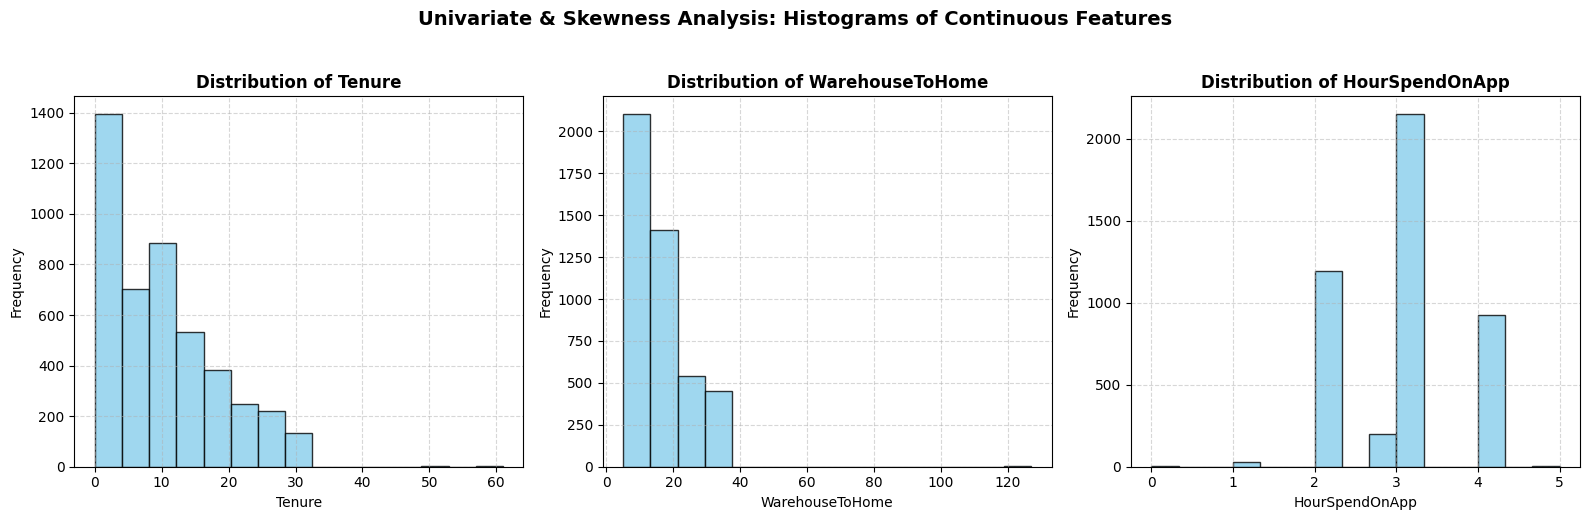

In [33]:
# Task I - Histogram for Tenure, WarehouseToHome and HourSpendOnApp

import matplotlib.pyplot as plt

histogram_features = ['Tenure', 'WarehouseToHome', 'HourSpendOnApp']

# Setting up a 1-row, 3-column canvas using subplot function
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for i, col in enumerate(histogram_features):
    ax = axes[i]
    data = df_cleaned[col].dropna()

    ax.hist(data, bins=15, color='skyblue', edgecolor='black', alpha=0.8)

    ax.set_title(f'Distribution of {col}', fontsize=12, fontweight='bold')
    ax.set_xlabel(col, fontsize=10)
    ax.set_ylabel('Frequency', fontsize=10)

    ax.grid(True, linestyle='--', alpha=0.5)

plt.suptitle('Univariate & Skewness Analysis: Histograms of Continuous Features', fontsize=14, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

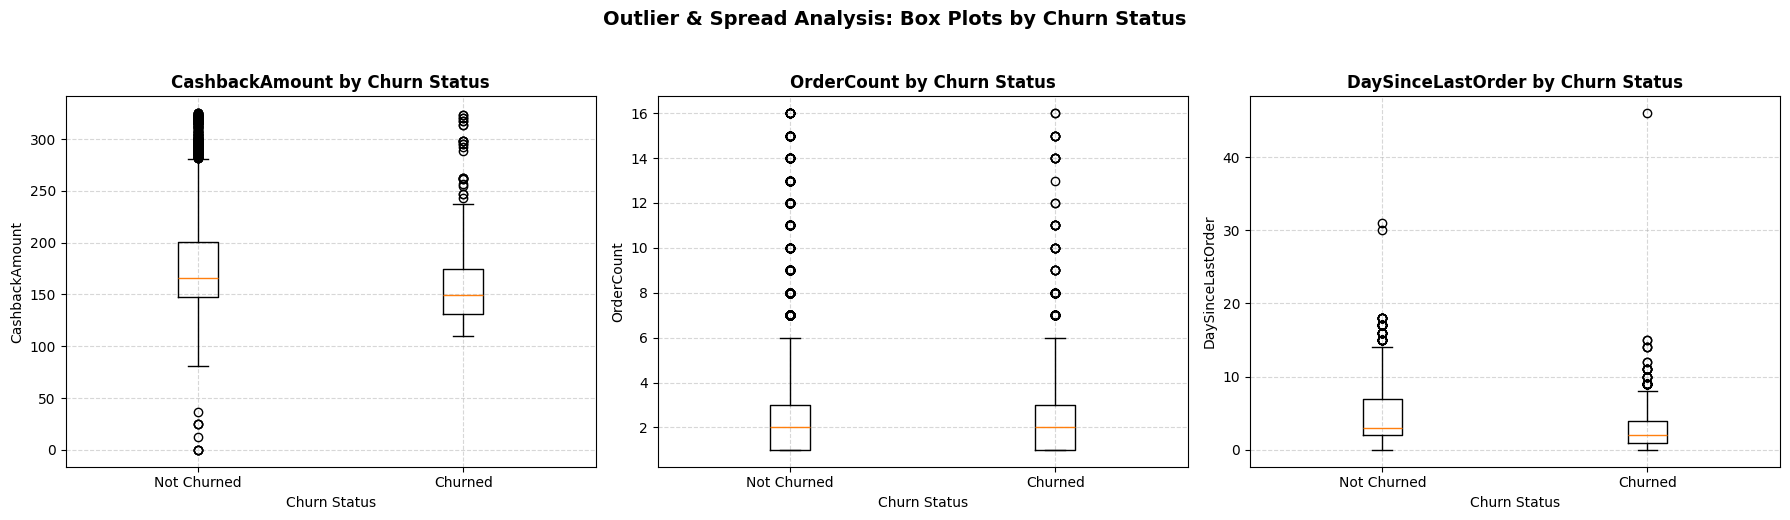

In [34]:
# Task I - Box Plot
boxplot_features = ['CashbackAmount', 'OrderCount', 'DaySinceLastOrder']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, col in enumerate(boxplot_features):
    ax = axes[i]
    not_churned = df_cleaned[df_cleaned["Churn"] == 0][col].dropna()
    churned = df_cleaned[df_cleaned["Churn"] == 1][col].dropna()

    ax.boxplot([not_churned, churned], tick_labels=["Not Churned", "Churned"])
    ax.set_title(f'{col} by Churn Status', fontsize=12, fontweight='bold')
    ax.set_xlabel('Churn Status', fontsize=10)
    ax.set_ylabel(col, fontsize=10)
    ax.grid(True, linestyle='--', alpha=0.5)

plt.suptitle('Outlier & Spread Analysis: Box Plots by Churn Status', fontsize=14, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

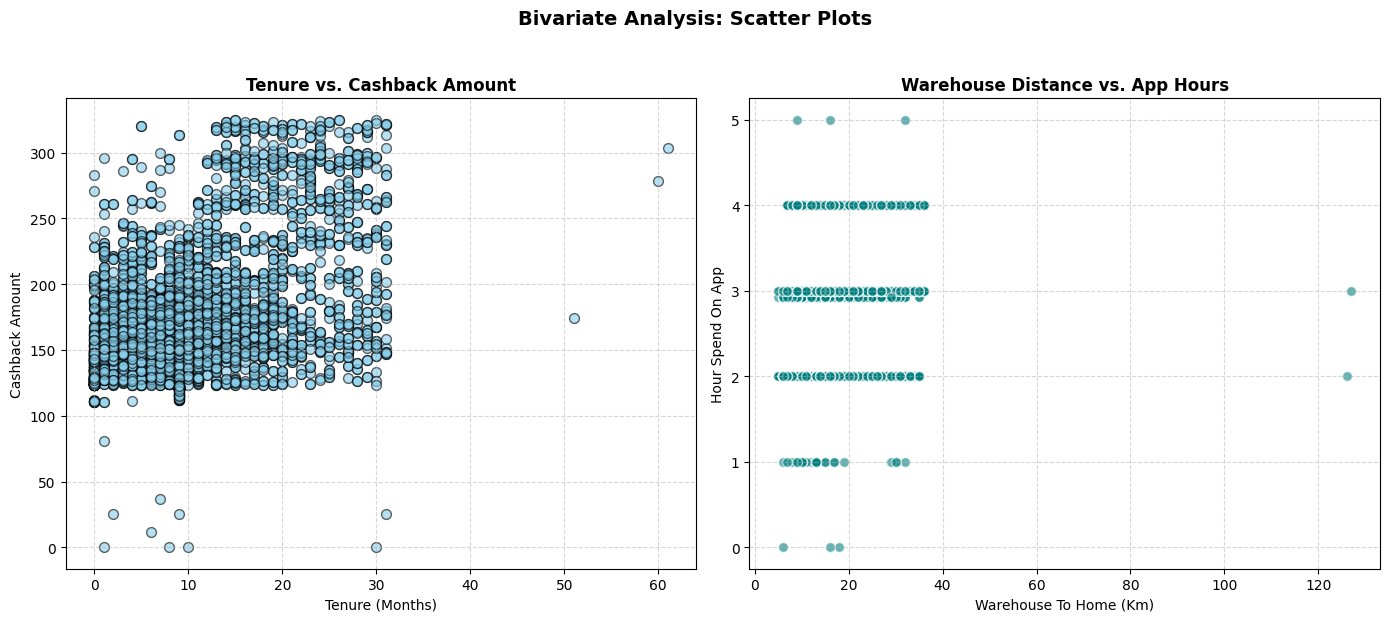

In [35]:
# Task I - Scatter Plot of Tenure vs CashBackAmount and WarehouseToHome vs HourSpendOnApp

import matplotlib.pyplot as plt

# Setting up a 1-row, 2-column canvas using subplot function
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

ax1 = axes[0]
ax1.scatter(df_cleaned['Tenure'], df_cleaned['CashbackAmount'],
            color='skyblue', alpha=0.6, edgecolors='black', s=50)
ax1.set_title('Tenure vs. Cashback Amount', fontsize=12, fontweight='bold')
ax1.set_xlabel('Tenure (Months)', fontsize=10)
ax1.set_ylabel('Cashback Amount', fontsize=10)
ax1.grid(True, linestyle='--', alpha=0.5)

ax2 = axes[1]
ax2.scatter(df_cleaned['WarehouseToHome'], df_cleaned['HourSpendOnApp'],
            color='teal', alpha=0.6, edgecolors='w', s=50)
ax2.set_title('Warehouse Distance vs. App Hours', fontsize=12, fontweight='bold')
ax2.set_xlabel('Warehouse To Home (Km)', fontsize=10)
ax2.set_ylabel('Hour Spend On App', fontsize=10)
ax2.grid(True, linestyle='--', alpha=0.5)

plt.suptitle('Bivariate Analysis: Scatter Plots', fontsize=14, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

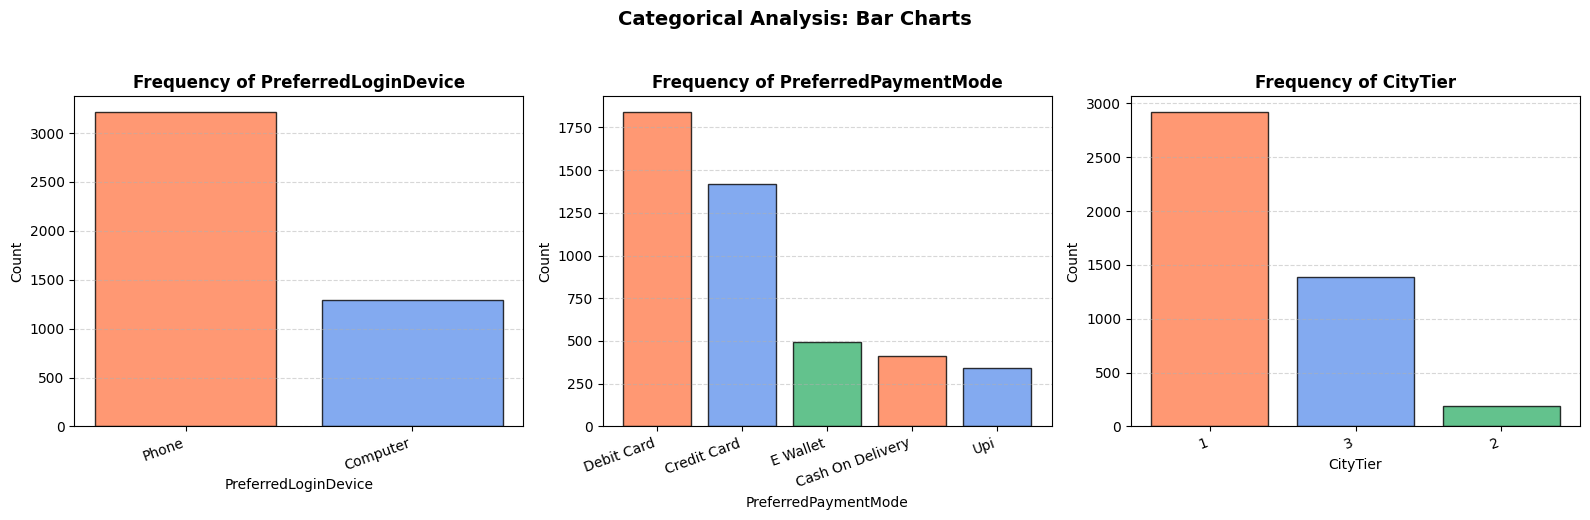

In [36]:

# Task I - Bar chart for PreferredLoginDevice, PreferredPaymentMode and CityTier

import matplotlib.pyplot as plt

bar_features = ['PreferredLoginDevice', 'PreferredPaymentMode', 'CityTier']

# Setting up a 1-row, 3-column canvas using subplot function
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for i, col in enumerate(bar_features):
    ax = axes[i]

    counts = df_cleaned[col].value_counts()
    categories = [str(cat) for cat in counts.index]
    values = counts.values

    ax.bar(categories, values, color=['coral', 'cornflowerblue', 'mediumseagreen'], edgecolor='black', alpha=0.8)

    ax.set_title(f'Frequency of {col}', fontsize=12, fontweight='bold')
    ax.set_xlabel(col, fontsize=10)
    ax.set_ylabel('Count', fontsize=10)

    # Rotating x-tick labels because the text is long (especially for payment modes)
    plt.setp(ax.get_xticklabels(), rotation=20, ha='right')

    ax.grid(True, axis='y', linestyle='--', alpha=0.5)

plt.suptitle('Categorical Analysis: Bar Charts', fontsize=14, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

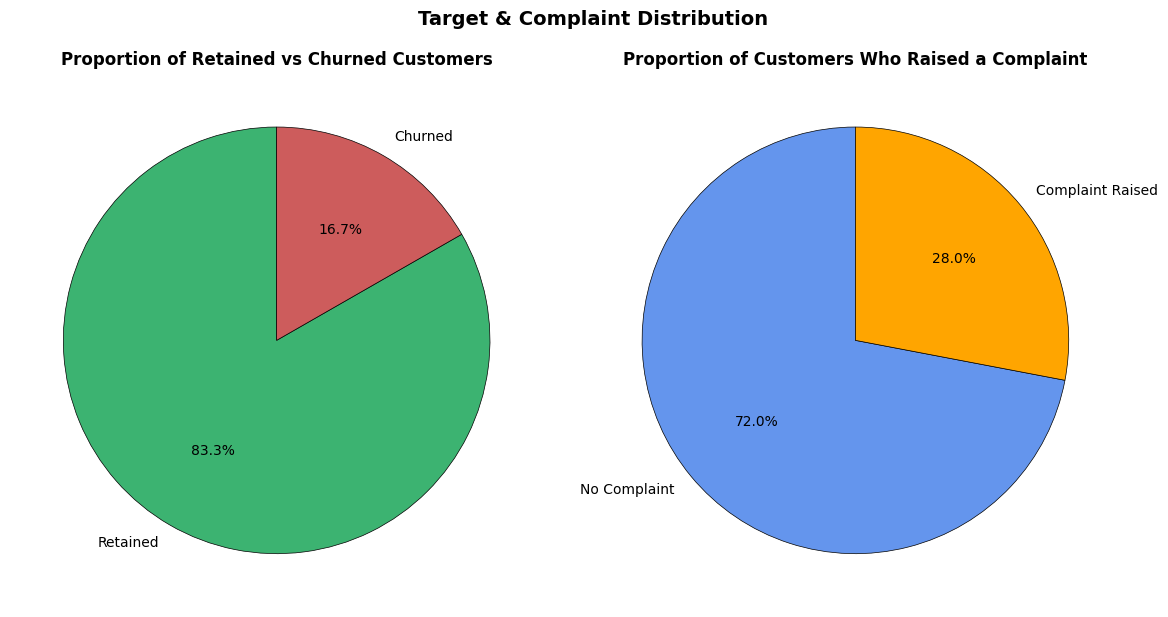

In [37]:
# Task I  - Pie Charts for Churn and Complain proportions
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# --- Pie 1: Churn proportion ---
churn_counts = df_cleaned["Churn"].value_counts()
churn_labels = ["Retained", "Churned"]

axes[0].pie(churn_counts, labels=churn_labels, autopct='%1.1f%%',
            colors=['mediumseagreen', 'indianred'], startangle=90,
            wedgeprops={'edgecolor': 'black', 'linewidth': 0.5})
axes[0].set_title('Proportion of Retained vs Churned Customers', fontsize=12, fontweight='bold')

# Pie 2: Complain proportion
complain_counts = df_cleaned["Complain"].value_counts()
complain_labels = ["No Complaint", "Complaint Raised"]

axes[1].pie(complain_counts, labels=complain_labels, autopct='%1.1f%%',
            colors=['cornflowerblue', 'orange'], startangle=90,
            wedgeprops={'edgecolor': 'black', 'linewidth': 0.5})
axes[1].set_title('Proportion of Customers Who Raised a Complaint', fontsize=12, fontweight='bold')

plt.suptitle('Target & Complaint Distribution', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

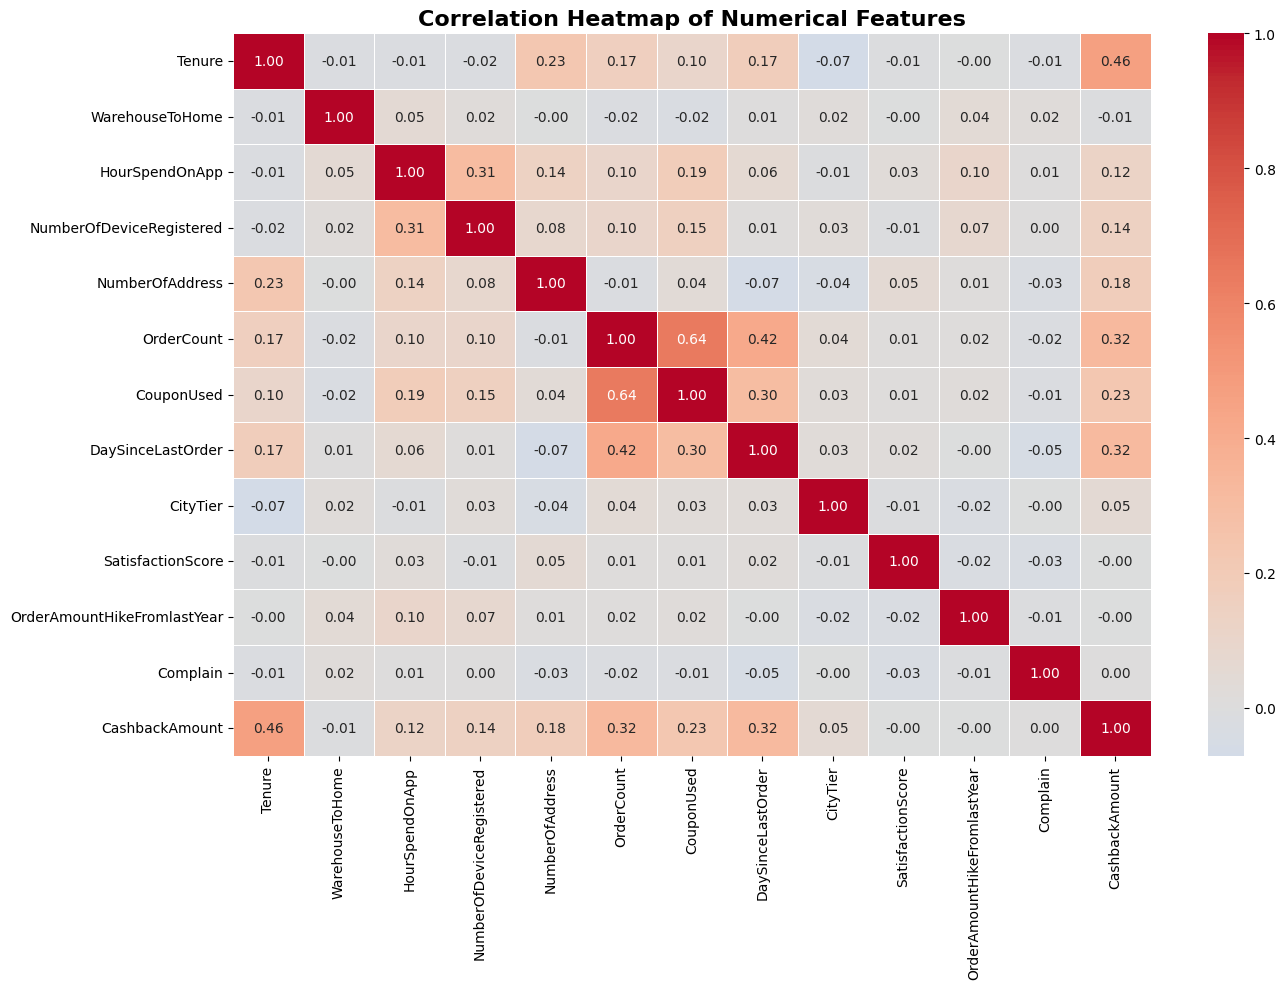

In [38]:
# Task I - Correlation Heatmap of Numerical Features
import seaborn as sns

correlation_matrix = pd.DataFrame(0.0,index=features_to_test,columns=features_to_test)

for col1 in features_to_test:
    for col2 in features_to_test:

        x = df_cleaned[col1].values
        y = df_cleaned[col2].values

        mean_x = np.mean(x)
        mean_y = np.mean(y)

        numerator = 0
        denominator_x = 0
        denominator_y = 0

        for i in range(len(x)):
            numerator += (x[i] - mean_x) * (y[i] - mean_y)
            denominator_x += (x[i] - mean_x) ** 2
            denominator_y += (y[i] - mean_y) ** 2

        correlation = numerator / np.sqrt(
            denominator_x * denominator_y
        )

        correlation_matrix.loc[col1, col2] = correlation

correlation_matrix

# Plot heatmap
plt.figure(figsize=(14, 10))

sns.heatmap(correlation_matrix,annot=True,fmt=".2f",cmap="coolwarm",linewidths=0.5,center=0)

plt.title("Correlation Heatmap of Numerical Features",fontsize=16,fontweight="bold")

plt.tight_layout()
plt.show()

In [39]:

#  Train-Test Split (80/20)
# import random

# def train_test_split_manual(df, test_ratio=0.20, seed=42):

#     total_rows = len(df)

#     #  Get all row indices as a list
#     indices = list(df.index)

#     #  Shuffle them randomly
#     random.seed(seed)
#     random.shuffle(indices)

#     #  Calculate split point
#     test_size = int(total_rows * test_ratio)

#     # Slice the shuffled indices
#     test_indices = indices[:test_size]
#     train_indices = indices[test_size:]

#     #  Using these indices to create actual train/test dataframes
#     train_df = df.loc[train_indices]
#     test_df = df.loc[test_indices]

#     return train_df, test_df

# train_df, test_df = train_test_split_manual(df_cleaned, test_ratio=0.20, seed=42)

# # Save train and test datasets as CSV files
# train_df.to_csv("train_dataset.csv", index=False)
# test_df.to_csv("test_dataset.csv", index=False)

# print("Original dataset size:", len(df_cleaned))
# print("Training set size:", len(train_df), f"({len(train_df)/len(df_cleaned)*100:.1f}%)")
# print("Testing set size:", len(test_df), f"({len(test_df)/len(df_cleaned)*100:.1f}%)")

In [40]:
#  Library verification
# from sklearn.model_selection import train_test_split

# train_lib, test_lib = train_test_split(df_cleaned, test_size=0.20, random_state=42)

# print("Manual split sizes match sklearn split sizes:",
#       len(train_df) == len(train_lib) and len(test_df) == len(test_lib))

In [41]:
# Task M1
print("Total features being checked:", len(features_to_test))
print(features_to_test)

# --- Calculate variance for each selected feature ---
variance_report = []
def calc_mean(values):
    return sum(values) / len(values)

def calc_variance(values, mean_val):
    squared_diffs = [(v - mean_val) ** 2 for v in values]
    return sum(squared_diffs) / len(values)
for col in features_to_test:
    values = df_cleaned[col].dropna().tolist()
    mean_val = calc_mean(values)
    var_val = calc_variance(values, mean_val)
    variance_report.append({"Feature": col, "Variance": var_val})

variance_table = pd.DataFrame(variance_report).sort_values("Variance").reset_index(drop=True)
variance_table

# --- Library Verification using NumPy variance (np.var) ---
lib_variance_report = []

for col in features_to_test:
    values = df_cleaned[col].dropna().values
    lib_var = np.var(values, ddof=0)
    lib_variance_report.append({"Feature": col, "Lib Variance": lib_var})

lib_check = pd.DataFrame(lib_variance_report)

merged_check = variance_table.merge(lib_check, on="Feature")
merged_check["Match"] = np.isclose(merged_check["Variance"], merged_check["Lib Variance"], atol=1e-6)

print("Library Verification using NumPy (np.var) for M1 Task")
merged_check[["Feature", "Variance", "Lib Variance", "Match"]]



Total features being checked: 13
['Tenure', 'WarehouseToHome', 'HourSpendOnApp', 'NumberOfDeviceRegistered', 'NumberOfAddress', 'OrderCount', 'CouponUsed', 'DaySinceLastOrder', 'CityTier', 'SatisfactionScore', 'OrderAmountHikeFromlastYear', 'Complain', 'CashbackAmount']
Library Verification using NumPy (np.var) for M1 Task


,Feature,Variance,Lib Variance,Match
0,Complain,0.201588,0.201588,True
1,HourSpendOnApp,0.499149,0.499149,True
2,CityTier,0.841905,0.841905,True
3,NumberOfDeviceRegistered,1.031634,1.031634,True
4,SatisfactionScore,1.921621,1.921621,True
5,CouponUsed,3.357771,3.357771,True
6,NumberOfAddress,6.634182,6.634182,True
7,OrderCount,8.390976,8.390976,True
8,OrderAmountHikeFromlastYear,12.905129,12.905129,True
9,DaySinceLastOrder,12.905202,12.905202,True


In [42]:
# --- Classify + decide Keep/Remove
def classify_variance(v):
    if v == 0:
        return "Zero-variance"
    elif v < 0.01:
        return "Near-zero-variance"
    elif v < 1:
        return "Low-variance"
    else:
        return "Acceptable"

variance_table["Category"] = variance_table["Variance"].apply(classify_variance)

variance_table["Decision"] = variance_table["Category"].apply(
    lambda c: "Remove" if c in ["Zero-variance", "Near-zero-variance"] else "Keep"
)

variance_table["Reason"] = variance_table.apply(
    lambda row: f"{row['Category']} ({row['Variance']:.4f}) -> little/no discriminatory information"
    if row["Decision"] == "Remove"
    else f"{row['Category']} ({row['Variance']:.4f}) -> sufficient spread, potentially useful",
    axis=1
)

print("Task M1: Variance Threshold completed successfully from scratch!\n")
variance_table

Task M1: Variance Threshold completed successfully from scratch!



,Feature,Variance,Category,Decision,Reason
0,Complain,0.201588,Low-variance,Keep,"Low-variance (0.2016) -> sufficient spread, po..."
1,HourSpendOnApp,0.499149,Low-variance,Keep,"Low-variance (0.4991) -> sufficient spread, po..."
2,CityTier,0.841905,Low-variance,Keep,"Low-variance (0.8419) -> sufficient spread, po..."
3,NumberOfDeviceRegistered,1.031634,Acceptable,Keep,"Acceptable (1.0316) -> sufficient spread, pote..."
4,SatisfactionScore,1.921621,Acceptable,Keep,"Acceptable (1.9216) -> sufficient spread, pote..."
5,CouponUsed,3.357771,Acceptable,Keep,"Acceptable (3.3578) -> sufficient spread, pote..."
6,NumberOfAddress,6.634182,Acceptable,Keep,"Acceptable (6.6342) -> sufficient spread, pote..."
7,OrderCount,8.390976,Acceptable,Keep,"Acceptable (8.3910) -> sufficient spread, pote..."
8,OrderAmountHikeFromlastYear,12.905129,Acceptable,Keep,"Acceptable (12.9051) -> sufficient spread, pot..."
9,DaySinceLastOrder,12.905202,Acceptable,Keep,"Acceptable (12.9052) -> sufficient spread, pot..."


In [43]:
# M2: Pearson Correlation Function

print("Number of numerical features:", len(features_to_test))
print(features_to_test)

def calc_pearson(x, y):

    # Remove rows where either value is missing
    paired_values = []

    for i in range(len(x)):
        if pd.notna(x[i]) and pd.notna(y[i]):
            paired_values.append((x[i], y[i]))

    x_clean = [pair[0] for pair in paired_values]
    y_clean = [pair[1] for pair in paired_values]

    # Calculate means
    mean_x = calc_mean(x_clean)
    mean_y = calc_mean(y_clean)

    # Calculate numerator and denominator
    numerator = 0
    sum_x_squared = 0
    sum_y_squared = 0

    for i in range(len(x_clean)):

        x_diff = x_clean[i] - mean_x
        y_diff = y_clean[i] - mean_y

        numerator += x_diff * y_diff
        sum_x_squared += x_diff ** 2
        sum_y_squared += y_diff ** 2

    denominator = (sum_x_squared * sum_y_squared) ** 0.5

    # Avoid division by zero
    if denominator == 0:
        return 0

    return numerator / denominator

Number of numerical features: 13
['Tenure', 'WarehouseToHome', 'HourSpendOnApp', 'NumberOfDeviceRegistered', 'NumberOfAddress', 'OrderCount', 'CouponUsed', 'DaySinceLastOrder', 'CityTier', 'SatisfactionScore', 'OrderAmountHikeFromlastYear', 'Complain', 'CashbackAmount']


In [44]:
# M2: Feature-Target Correlation

feature_target_results = []

for feature in features_to_test:

    x = df_cleaned[feature].tolist()
    y = df_cleaned[target_col].tolist()

    correlation = calc_pearson(x, y)

    feature_target_results.append({
        "Feature": feature,
        "Target": target_col,
        "Pearson Correlation": correlation
    })

feature_target_table = pd.DataFrame(feature_target_results)

feature_target_table["Pearson Correlation"] = \
    feature_target_table["Pearson Correlation"].round(4)

display(feature_target_table)

,Feature,Target,Pearson Correlation
0,Tenure,Churn,-0.3406
1,WarehouseToHome,Churn,0.0674
2,HourSpendOnApp,Churn,0.0191
3,NumberOfDeviceRegistered,Churn,0.1114
4,NumberOfAddress,Churn,0.0460
5,OrderCount,Churn,-0.0317
6,CouponUsed,Churn,-0.0084
7,DaySinceLastOrder,Churn,-0.1572
8,CityTier,Churn,0.0769
9,SatisfactionScore,Churn,0.1134


In [45]:
# M2: Feature-Feature Correlation Matrix

correlation_matrix = pd.DataFrame(
    0.0,
    index=features_to_test,
    columns=features_to_test
)

for i in range(len(features_to_test)):

    for j in range(len(features_to_test)):

        feature_1 = features_to_test[i]
        feature_2 = features_to_test[j]

        x = df_cleaned[feature_1].tolist()
        y = df_cleaned[feature_2].tolist()

        correlation = calc_pearson(x, y)

        correlation_matrix.loc[
            feature_1,
            feature_2
        ] = correlation

display(correlation_matrix.round(4))

,Tenure,WarehouseToHome,HourSpendOnApp,NumberOfDeviceRegistered,NumberOfAddress,OrderCount,CouponUsed,DaySinceLastOrder,CityTier,SatisfactionScore,OrderAmountHikeFromlastYear,Complain,CashbackAmount
Tenure,1.0000,-0.0136,-0.0144,-0.0151,0.2323,0.1669,0.0978,0.1748,-0.0712,-0.0117,-0.0026,-0.0135,0.4638
WarehouseToHome,-0.0136,1.0000,0.0540,0.0201,-0.0002,-0.0179,-0.0213,0.0077,0.0190,-0.0033,0.0434,0.0168,-0.0112
HourSpendOnApp,-0.0144,0.0540,1.0000,0.3054,0.1385,0.1021,0.1871,0.0583,-0.0084,0.0293,0.0999,0.0076,0.1234
NumberOfDeviceRegistered,-0.0151,0.0201,0.3054,1.0000,0.0846,0.1003,0.1539,0.0130,0.0316,-0.0084,0.0722,0.0021,0.1444
NumberOfAddress,0.2323,-0.0002,0.1385,0.0846,1.0000,-0.0135,0.0350,-0.0659,-0.0397,0.0533,0.0087,-0.0277,0.1780
OrderCount,0.1669,-0.0179,0.1021,0.1003,-0.0135,1.0000,0.6435,0.4201,0.0424,0.0121,0.0164,-0.0170,0.3249
CouponUsed,0.0978,-0.0213,0.1871,0.1539,0.0350,0.6435,1.0000,0.2983,0.0288,0.0116,0.0242,-0.0143,0.2297
DaySinceLastOrder,0.1748,0.0077,0.0583,0.0130,-0.0659,0.4201,0.2983,1.0000,0.0253,0.0243,-0.0005,-0.0464,0.3169
CityTier,-0.0712,0.0190,-0.0084,0.0316,-0.0397,0.0424,0.0288,0.0253,1.0000,-0.0109,-0.0229,-0.0010,0.0502
SatisfactionScore,-0.0117,-0.0033,0.0293,-0.0084,0.0533,0.0121,0.0116,0.0243,-0.0109,1.0000,-0.0215,-0.0329,-0.0002


In [46]:

# M2: Identify Potentially Redundant Features

correlation_threshold = 0.80

redundant_features = []

for i in range(len(features_to_test)):

    for j in range(i + 1, len(features_to_test)):

        feature_1 = features_to_test[i]
        feature_2 = features_to_test[j]

        correlation = correlation_matrix.loc[
            feature_1,
            feature_2
        ]

        if abs(correlation) >= correlation_threshold:

            redundant_features.append({
                "Feature 1": feature_1,
                "Feature 2": feature_2,
                "Pearson Correlation": round(correlation, 4)
            })

redundant_features_table = pd.DataFrame(
    redundant_features
)

if len(redundant_features_table) == 0:

    print(
        "No highly correlated feature pairs found "
        "at threshold", correlation_threshold
    )

else:

    display(redundant_features_table)

No highly correlated feature pairs found at threshold 0.8


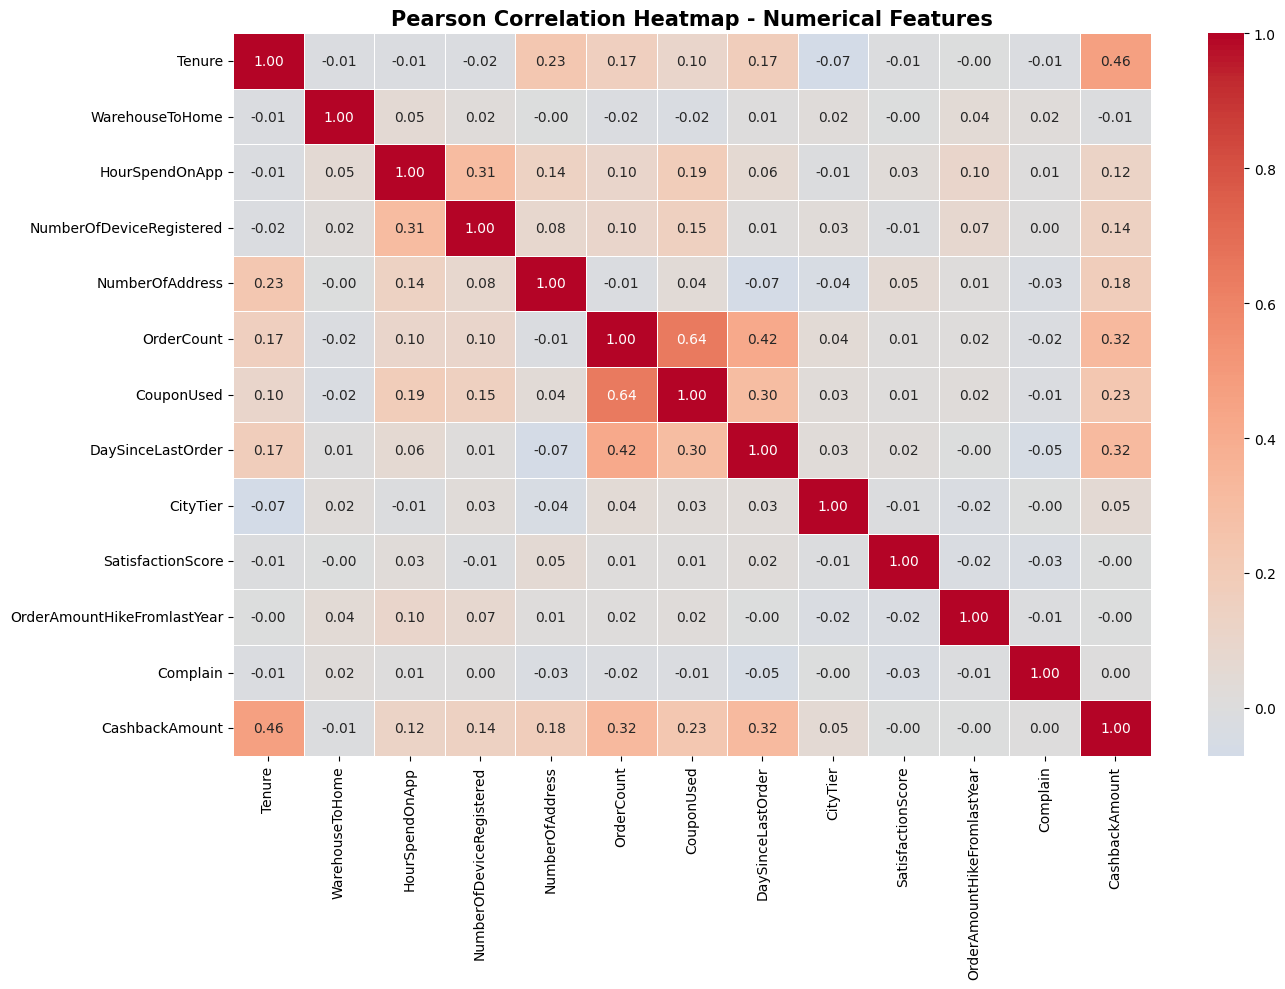

In [47]:
# M2: Pearson Correlation Heatmap

plt.figure(figsize=(14, 10))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)

plt.title(
    "Pearson Correlation Heatmap - Numerical Features",
    fontsize=15,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

In [48]:
# M2: Feature-Target Correlation Interpretation

def interpret_correlation(r):

    if abs(r) >= 0.80:
        strength = "Strong"
    elif abs(r) >= 0.50:
        strength = "Moderate"
    elif abs(r) >= 0.30:
        strength = "Weak"
    else:
        strength = "Very Weak / Near Zero"

    if r > 0:
        direction = "Positive"
    elif r < 0:
        direction = "Negative"
    else:
        direction = "Zero"

    return direction + " " + strength


interpretation_results = []

for row in feature_target_results:

    feature = row["Feature"]
    correlation = row["Pearson Correlation"]

    interpretation_results.append({
        "Feature": feature,
        "Correlation with Churn": round(correlation, 4),
        "Interpretation": interpret_correlation(correlation)
    })

interpretation_table = pd.DataFrame(
    interpretation_results
)

display(interpretation_table)

,Feature,Correlation with Churn,Interpretation
0,Tenure,-0.3406,Negative Weak
1,WarehouseToHome,0.0674,Positive Very Weak / Near Zero
2,HourSpendOnApp,0.0191,Positive Very Weak / Near Zero
3,NumberOfDeviceRegistered,0.1114,Positive Very Weak / Near Zero
4,NumberOfAddress,0.0460,Positive Very Weak / Near Zero
5,OrderCount,-0.0317,Negative Very Weak / Near Zero
6,CouponUsed,-0.0084,Negative Very Weak / Near Zero
7,DaySinceLastOrder,-0.1572,Negative Very Weak / Near Zero
8,CityTier,0.0769,Positive Very Weak / Near Zero
9,SatisfactionScore,0.1134,Positive Very Weak / Near Zero


In [49]:
# M2: Library Verification of Correlation Matrix

lib_correlation_matrix = df_cleaned[features_to_test].corr()

# Compare manual correlation matrix with library result
correlation_match = np.isclose(
    correlation_matrix.values,
    lib_correlation_matrix.values,
    atol=1e-6
)

print("All correlations match:",
      correlation_match.all())

All correlations match: True


In [50]:
# --- Task M3: Chi-Square Feature Selection
categorical_features_for_chi2 = ["Gender", "PreferredLoginDevice", "PreferredPaymentMode",
                                  "PreferedOrderCat", "MaritalStatus", "CityTier", "Complain"
                                ]

categorical_features_for_chi2 = [c for c in categorical_features_for_chi2 if c in df_cleaned.columns]
print("Features to test:", categorical_features_for_chi2)

# Contingency table + Observed frequencies ---
def build_contingency_table(df, feature_col, target_col):
    contingency = {}
    for _, row in df[[feature_col, target_col]].dropna().iterrows():
        f_val = row[feature_col]
        t_val = row[target_col]
        if f_val not in contingency:
            contingency[f_val] = {}
        contingency[f_val][t_val] = contingency[f_val].get(t_val, 0) + 1
    return contingency

def contingency_to_dataframe(contingency, target_categories):
    rows = []
    for f_val, counts in contingency.items():
        row = {"Category": f_val}
        for t_val in target_categories:
            row[f"Churn={t_val}"] = counts.get(t_val, 0)
        rows.append(row)
    return pd.DataFrame(rows).set_index("Category")
#  Expected frequencies, contributions, total Chi-Square, degrees of freedom ---
def calc_chi_square(contingency_df):
    row_totals = contingency_df.sum(axis=1)
    col_totals = contingency_df.sum(axis=0)
    grand_total = contingency_df.values.sum()

    expected_df = pd.DataFrame(index=contingency_df.index, columns=contingency_df.columns, dtype=float)
    chi2_contrib_df = pd.DataFrame(index=contingency_df.index, columns=contingency_df.columns, dtype=float)

    for row_cat in contingency_df.index:
        for col_cat in contingency_df.columns:
            O = contingency_df.loc[row_cat, col_cat]
            E = (row_totals[row_cat] * col_totals[col_cat]) / grand_total   # Expected frequency formula
            expected_df.loc[row_cat, col_cat] = E
            chi2_contrib_df.loc[row_cat, col_cat] = ((O - E) ** 2) / E if E != 0 else 0

    total_chi2 = chi2_contrib_df.values.sum()
    r = contingency_df.shape[0]
    c = contingency_df.shape[1]
    degrees_of_freedom = (r - 1) * (c - 1)

    return expected_df, chi2_contrib_df, total_chi2, degrees_of_freedom
  # --- Apply Chi-Square to every candidate feature ---
target_categories = sorted(df_cleaned["Churn"].dropna().unique())
chi2_summary = []
chi2_details = {}

for col in categorical_features_for_chi2:
    contingency_raw = build_contingency_table(df_cleaned, col, "Churn")
    contingency_df = contingency_to_dataframe(contingency_raw, target_categories)

    expected_df, chi2_contrib_df, total_chi2, dof = calc_chi_square(contingency_df)

    chi2_details[col] = {
        "Observed": contingency_df,
        "Expected": expected_df,
        "Contributions": chi2_contrib_df
    }

    chi2_summary.append({
        "Feature": col,
        "Chi-Square Statistic": round(total_chi2, 3),
        "Degrees of Freedom": dof
    })

chi2_table = pd.DataFrame(chi2_summary).sort_values("Chi-Square Statistic", ascending=False)
chi2_table


Features to test: ['Gender', 'PreferredLoginDevice', 'PreferredPaymentMode', 'PreferedOrderCat', 'MaritalStatus', 'CityTier', 'Complain']


,Feature,Chi-Square Statistic,Degrees of Freedom
6,Complain,274.194,1
3,PreferedOrderCat,242.619,4
4,MaritalStatus,154.810,2
2,PreferredPaymentMode,41.851,4
5,CityTier,27.917,2
1,PreferredLoginDevice,16.159,1
0,Gender,4.241,1


In [51]:
# --- Interpretation: compare p-value against alpha (significance level) ---
from scipy.stats import chi2 as chi2_dist

alpha = 0.05

chi2_table["p-value"] = chi2_table.apply(
    lambda row: 1 - chi2_dist.cdf(row["Chi-Square Statistic"], row["Degrees of Freedom"]),
    axis=1
)
chi2_table["Significant (p < alpha)"] = chi2_table["p-value"] < alpha

print(f"Using alpha (significance level) = {alpha}")
chi2_table

# --- Display one feature's full tables
sample_feature = chi2_table.iloc[0]["Feature"]

print(f"--- {sample_feature}: Observed Frequencies (Contingency Table) ---")
display(chi2_details[sample_feature]["Observed"])

print(f"\n--- {sample_feature}: Expected Frequencies ---")
display(chi2_details[sample_feature]["Expected"].round(2))

print(f"\n--- {sample_feature}: Chi-Square Contributions per Cell ---")
display(chi2_details[sample_feature]["Contributions"].round(3))

Using alpha (significance level) = 0.05
--- Complain: Observed Frequencies (Contingency Table) ---


,Churn=0,Churn=1
Category,,
0,2887,356
1,864,397



--- Complain: Expected Frequencies ---


,Churn=0,Churn=1
Category,,
0,2700.82,542.18
1,1050.18,210.82



--- Complain: Chi-Square Contributions per Cell ---


,Churn=0,Churn=1
Category,,
0,12.834,63.933
1,33.007,164.420


In [52]:
from scipy.stats import chi2_contingency

verify_rows = []
for col in categorical_features_for_chi2:
    ct = pd.crosstab(df_cleaned[col], df_cleaned["Churn"])
    lib_chi2, lib_p, lib_dof, _ = chi2_contingency(ct, correction=False)   # <-- disable Yates' correction

    my_row = chi2_table[chi2_table["Feature"] == col].iloc[0]
    verify_rows.append({
        "Feature": col,
        "My Chi2": my_row["Chi-Square Statistic"],
        "Lib Chi2 (no correction)": round(lib_chi2, 3),
        "Match": np.isclose(my_row["Chi-Square Statistic"], lib_chi2, atol=0.01)
    })

pd.DataFrame(verify_rows)

,Feature,My Chi2,Lib Chi2 (no correction),Match
0,Gender,4.241,4.241,True
1,PreferredLoginDevice,16.159,16.159,True
2,PreferredPaymentMode,41.851,41.851,True
3,PreferedOrderCat,242.619,242.619,True
4,MaritalStatus,154.810,154.810,True
5,CityTier,27.917,27.917,True
6,Complain,274.194,274.194,True


In [53]:
# M4: ANOVA F-TEST

import pandas as pd
import numpy as np
from scipy.stats import f as f_dist

features_for_anova = [col for col in features_to_test if col in df_cleaned.columns]
anova_df = df_cleaned[features_for_anova + ['Churn']].dropna()

anova_results_scratch = []

n = len(anova_df)
groups = anova_df['Churn'].unique()
k = len(groups)

# Degrees of freedom
df_between = k - 1
df_within = n - k

alpha = 0.05
critical_f_value = f_dist.ppf(1 - alpha, df_between, df_within)

for col in features_for_anova:
    all_values = anova_df[col].tolist()

    # Mean using custom B2 functions
    overall_mean = calc_mean(all_values)

    # Calculating SSB and SSW
    ssb = 0.0
    ssw = 0.0
    for g in groups:
        group_data = anova_df[anova_df['Churn'] == g][col].tolist()
        n_g = len(group_data)

        if n_g > 0:
            # Group Mean using custom B2 function
            g_mean = calc_mean(group_data)
            ssb += n_g * ((g_mean - overall_mean) ** 2)

            # SSW using custom B2 function
            g_var = calc_variance(group_data, g_mean)
            ssw += g_var * (n_g - 1)

    # Mean Squares
    ms_between = ssb / df_between if df_between > 0 else 0
    ms_within = ssw / df_within if df_within > 0 else 0

    # F-Statistic
    f_score = ms_between / ms_within if ms_within > 0 else 0.0

    is_significant = f_score > critical_f_value

    anova_results_scratch.append({
        'Feature': col,
        'F-Score (Scratch)': round(f_score, 4),
        'Critical F': round(critical_f_value, 4),
        'Significant (Alpha = 0.05)': is_significant,
        'SSB': round(ssb, 4),
        'SSW': round(ssw, 4)
    })

anova_scratch_table = pd.DataFrame(anova_results_scratch).sort_values(by='F-Score (Scratch)', ascending=False)

print("Task M4: ANOVA F-Test computed successfully from scratch using B2 functions!")
display(anova_scratch_table)

Task M4: ANOVA F-Test computed successfully from scratch using B2 functions!


,Feature,F-Score (Scratch),Critical F,Significant (Alpha = 0.05),SSB,SSW
0,Tenure,591.1992,3.8435,True,36639.5913,2.790116e+05
11,Complain,291.9845,3.8435,True,55.2742,8.522528e+02
7,DaySinceLastOrder,114.0729,3.8435,True,1435.7984,5.666520e+04
12,CashbackAmount,112.8915,3.8435,True,267038.7051,1.064924e+07
9,SatisfactionScore,58.6626,3.8435,True,111.2787,8.539967e+03
3,NumberOfDeviceRegistered,56.5507,3.8435,True,57.6163,4.586829e+03
8,CityTier,26.8123,3.8435,True,22.4394,3.767766e+03
1,WarehouseToHome,20.5784,3.8435,True,1438.9372,3.148001e+05
4,NumberOfAddress,9.5425,3.8435,True,63.1708,2.980310e+04
5,OrderCount,4.5357,3.8435,True,38.0218,3.773910e+04


In [56]:
# --- Task M5: Mutual Information (from scratch) ---
import math

def calc_entropy(values):
    """H(Y) = -sum(P(y) * log2(P(y))) for each category y"""
    n = len(values)
    freq = {}
    for v in values:
        freq[v] = freq.get(v, 0) + 1

    entropy = 0
    for count in freq.values():
        p = count / n
        entropy += -p * math.log2(p)
    return entropy

In [57]:
def calc_conditional_entropy(feature_values, target_values):
    """H(Y|X) = sum over x of [ P(x) * H(Y | X=x) ]"""
    n = len(feature_values)

    # Group target values by each feature category
    groups = {}
    for f_val, t_val in zip(feature_values, target_values):
        groups.setdefault(f_val, []).append(t_val)

    conditional_entropy = 0
    for f_val, t_vals_in_group in groups.items():
        p_x = len(t_vals_in_group) / n          # P(X = this category)
        h_y_given_x = calc_entropy(t_vals_in_group)  # entropy of Y, WITHIN this one category
        conditional_entropy += p_x * h_y_given_x

    return conditional_entropy

In [58]:
def calc_mutual_information(feature_values, target_values):
    """MI(X;Y) = H(Y) - H(Y|X)"""
    h_y = calc_entropy(target_values)
    h_y_given_x = calc_conditional_entropy(feature_values, target_values)
    mi = h_y - h_y_given_x
    return h_y, h_y_given_x, mi

In [59]:
# --- Apply MI to your discrete/categorical features (same list as M3's Chi-Square) ---
mi_features = ["Gender", "PreferredLoginDevice", "PreferredPaymentMode",
               "PreferedOrderCat", "MaritalStatus", "CityTier", "Complain",
               "SatisfactionScore"]

mi_features = [c for c in mi_features if c in df_cleaned.columns]

mi_report = []
for col in mi_features:
    paired = df_cleaned[[col, "Churn"]].dropna()
    feature_values = paired[col].tolist()
    target_values = paired["Churn"].tolist()

    h_y, h_y_given_x, mi = calc_mutual_information(feature_values, target_values)

    mi_report.append({
        "Feature": col,
        "H(Y) - Entropy of Churn": round(h_y, 4),
        "H(Y|X) - Conditional Entropy": round(h_y_given_x, 4),
        "Mutual Information": round(mi, 4)
    })

mi_table = pd.DataFrame(mi_report).sort_values("Mutual Information", ascending=False)
mi_table

,Feature,H(Y) - Entropy of Churn,H(Y|X) - Conditional Entropy,Mutual Information
6,Complain,0.6512,0.6111,0.0402
3,PreferedOrderCat,0.6512,0.6118,0.0394
4,MaritalStatus,0.6512,0.6276,0.0236
7,SatisfactionScore,0.6512,0.6412,0.0100
2,PreferredPaymentMode,0.6512,0.6449,0.0063
5,CityTier,0.6512,0.6469,0.0044
1,PreferredLoginDevice,0.6512,0.6487,0.0025
0,Gender,0.6512,0.6505,0.0007


In [60]:
# --- Detailed worked example for ONE feature, showing every step (PDF requires at least one) ---
sample_feature = mi_table.iloc[0]["Feature"]
paired = df_cleaned[[sample_feature, "Churn"]].dropna()

print(f"--- Worked Example: {sample_feature} ---\n")

# Step 1: H(Y) - overall entropy of Churn
h_y = calc_entropy(paired["Churn"].tolist())
print(f"H(Churn) = {h_y:.4f} bits")

# Step 2: H(Y|X) - conditional entropy, broken down by category
groups = paired.groupby(sample_feature)["Churn"].apply(list)
n_total = len(paired)

print(f"\nBreakdown by {sample_feature} category:")
h_y_given_x_manual = 0
for category, churn_list in groups.items():
    p_x = len(churn_list) / n_total
    h_within_group = calc_entropy(churn_list)
    contribution = p_x * h_within_group
    h_y_given_x_manual += contribution
    print(f"  {sample_feature}={category}: P(X)={p_x:.4f}, H(Y|X={category})={h_within_group:.4f}, contributes {contribution:.4f}")

print(f"\nH(Churn | {sample_feature}) = {h_y_given_x_manual:.4f} bits")
print(f"Mutual Information = H(Y) - H(Y|X) = {h_y:.4f} - {h_y_given_x_manual:.4f} = {h_y - h_y_given_x_manual:.4f} bits")

--- Worked Example: Complain ---

H(Churn) = 0.6512 bits

Breakdown by Complain category:
  Complain=0: P(X)=0.7200, H(Y|X=0)=0.4992, contributes 0.3595
  Complain=1: P(X)=0.2800, H(Y|X=1)=0.8987, contributes 0.2516

H(Churn | Complain) = 0.6111 bits
Mutual Information = H(Y) - H(Y|X) = 0.6512 - 0.6111 = 0.0402 bits


In [61]:
# --- Library verification (sklearn mutual_info_score, check only) ---
from sklearn.metrics import mutual_info_score

verify_rows = []
for col in mi_features:
    paired = df_cleaned[[col, "Churn"]].dropna()
    lib_mi_nats = mutual_info_score(paired[col], paired["Churn"])   # sklearn returns NATURAL LOG (nats), not bits
    lib_mi_bits = lib_mi_nats / math.log(2)                          # convert nats -> bits to match your formula

    my_row = mi_table[mi_table["Feature"] == col].iloc[0]
    verify_rows.append({
        "Feature": col,
        "My MI (bits)": my_row["Mutual Information"],
        "Lib MI (bits)": round(lib_mi_bits, 4),
        "Match": np.isclose(my_row["Mutual Information"], lib_mi_bits, atol=1e-4)
    })

pd.DataFrame(verify_rows)

,Feature,My MI (bits),Lib MI (bits),Match
0,Gender,0.0007,0.0007,True
1,PreferredLoginDevice,0.0025,0.0025,True
2,PreferredPaymentMode,0.0063,0.0063,True
3,PreferedOrderCat,0.0394,0.0394,True
4,MaritalStatus,0.0236,0.0236,True
5,CityTier,0.0044,0.0044,True
6,Complain,0.0402,0.0402,True
7,SatisfactionScore,0.0100,0.0100,True


In [54]:
# TASK M6: FEATURE SELECTION MAPPING TABLE

import pandas as pd

feature_selection_mapping_table = [
    {
        "Method": "Variance Threshold",
        "Features": "Tenure, WarehouseToHome, HourSpendOnApp, NumberOfDeviceRegistered, NumberOfAddress, OrderCount, CouponUsed, DaySinceLastOrder, CityTier, SatisfactionScore, OrderAmountHikeFromlastYear, Complain, CashbackAmount",
        "Feature Type": "Numerical",
        "Target Type": "Not required",
        "Main Purpose": "Detect low-variance features"
    },
    {
        "Method": "Pearson Correlation",
        "Features": "Tenure, WarehouseToHome, HourSpendOnApp, NumberOfDeviceRegistered, NumberOfAddress, OrderCount, CouponUsed, DaySinceLastOrder, CityTier, SatisfactionScore, OrderAmountHikeFromlastYear, Complain, CashbackAmount",
        "Feature Type": "Numerical",
        "Target Type": "Numerical",
        "Main Purpose": "Linear relationship evaluation"
    },
    {
        "Method": "Chi-Square Test",
        "Features": "Gender, PreferredLoginDevice, PreferredPaymentMode, PreferedOrderCat, MaritalStatus, CityTier, Complain",
        "Feature Type": "Categorical/Discrete",
        "Target Type": "Categorical",
        "Main Purpose": "Statistical dependence of categories"
    },
    {
        "Method": "ANOVA F-Test",
        "Features": "Tenure, WarehouseToHome, HourSpendOnApp, NumberOfDeviceRegistered, NumberOfAddress, OrderCount, CouponUsed, DaySinceLastOrder, CityTier, SatisfactionScore, OrderAmountHikeFromlastYear, Complain, CashbackAmount",
        "Feature Type": "Numerical",
        "Target Type": "Categorical",
        "Main Purpose": "Difference across target groups [Churn]"
    }
]

pd.set_option('display.max_colwidth', None)
df_mapping_table = pd.DataFrame(feature_selection_mapping_table)

print("Task M6: Updated Feature Selection Technique & Feature Mapping Table")
display(df_mapping_table)

Task M6: Updated Feature Selection Technique & Feature Mapping Table


,Method,Features,Feature Type,Target Type,Main Purpose
0,Variance Threshold,"Tenure, WarehouseToHome, HourSpendOnApp, NumberOfDeviceRegistered, NumberOfAddress, OrderCount, CouponUsed, DaySinceLastOrder, CityTier, SatisfactionScore, OrderAmountHikeFromlastYear, Complain, CashbackAmount",Numerical,Not required,Detect low-variance features
1,Pearson Correlation,"Tenure, WarehouseToHome, HourSpendOnApp, NumberOfDeviceRegistered, NumberOfAddress, OrderCount, CouponUsed, DaySinceLastOrder, CityTier, SatisfactionScore, OrderAmountHikeFromlastYear, Complain, CashbackAmount",Numerical,Numerical,Linear relationship evaluation
2,Chi-Square Test,"Gender, PreferredLoginDevice, PreferredPaymentMode, PreferedOrderCat, MaritalStatus, CityTier, Complain",Categorical/Discrete,Categorical,Statistical dependence of categories
3,ANOVA F-Test,"Tenure, WarehouseToHome, HourSpendOnApp, NumberOfDeviceRegistered, NumberOfAddress, OrderCount, CouponUsed, DaySinceLastOrder, CityTier, SatisfactionScore, OrderAmountHikeFromlastYear, Complain, CashbackAmount",Numerical,Categorical,Difference across target groups [Churn]


In [55]:


# TASK M7: FINAL DECISION TABLE

import pandas as pd

final_decision_table = [
    {
        "Feature": "Tenure",
        "Data Type": "Numerical",
        "Tests Used": "Var, Pearson, ANOVA",
        "Scores": "Var: 70.10 | r: -0.3406 | F: 591.20",
        "Keep/Remove": "Keep",
        "Justification": "High variance spread; strong negative linear correlation and massive ANOVA F-score (Sig)."
    },
    {
        "Feature": "Complain",
        "Data Type": "Binary / Categorical",
        "Tests Used": "Var, Pearson, Chi2, ANOVA",
        "Scores": "Var: 0.20 | r: 0.2467 | Chi2: 274.19 | F: 291.98",
        "Keep/Remove": "Keep",
        "Justification": "Exceptional statistical dependence with churn across all metric tests."
    },
    {
        "Feature": "DaySinceLastOrder",
        "Data Type": "Numerical",
        "Tests Used": "Var, Pearson, ANOVA",
        "Scores": "Var: 12.91 | r: -0.1572 | F: 114.07",
        "Keep/Remove": "Keep",
        "Justification": "Healthy variance, meaningful negative correlation, and high ANOVA F-score (Sig)."
    },
    {
        "Feature": "CashbackAmount",
        "Data Type": "Numerical",
        "Tests Used": "Var, Pearson, ANOVA",
        "Scores": "Var: 2424.58 | r: -0.1564 | F: 112.89",
        "Keep/Remove": "Keep",
        "Justification": "Massive variance spread, robust linear correlation, and significant ANOVA F-score."
    },
    {
        "Feature": "SatisfactionScore",
        "Data Type": "Numerical / Discrete",
        "Tests Used": "Var, Pearson, Chi2, ANOVA",
        "Scores": "Var: 1.92 | r: 0.1134 | Chi2: 63.77 | F: 58.66",
        "Keep/Remove": "Keep",
        "Justification": "Passed variance check; strong performance across both Chi-Square and ANOVA."
    },
    {
        "Feature": "NumberOfDeviceRegistered",
        "Data Type": "Numerical",
        "Tests Used": "Var, Pearson, ANOVA",
        "Scores": "Var: 1.03 | r: 0.1114 | F: 56.55",
        "Keep/Remove": "Keep",
        "Justification": "Acceptable variance and well above the critical ANOVA threshold (3.84)."
    },
    {
        "Feature": "CityTier",
        "Data Type": "Numerical / Discrete",
        "Tests Used": "Var, Pearson, Chi2, ANOVA",
        "Scores": "Var: 0.84 | r: 0.0769 | Chi2: 27.92 | F: 26.81",
        "Keep/Remove": "Keep",
        "Justification": "Sufficient variance and solid statistical dependence indicators."
    },
    {
        "Feature": "WarehouseToHome",
        "Data Type": "Numerical",
        "Tests Used": "Var, Pearson, ANOVA",
        "Scores": "Var: 70.24 | r: 0.0674 | F: 20.58",
        "Keep/Remove": "Keep",
        "Justification": "High variance spread and clear significance in ANOVA testing."
    },
    {
        "Feature": "NumberOfAddress",
        "Data Type": "Numerical",
        "Tests Used": "Var, Pearson, ANOVA",
        "Scores": "Var: 6.63 | r: 0.0460 | F: 9.54",
        "Keep/Remove": "Keep",
        "Justification": "Acceptable variance and clears the critical ANOVA threshold."
    },
    {
        "Feature": "OrderCount",
        "Data Type": "Numerical",
        "Tests Used": "Var, Pearson, ANOVA",
        "Scores": "Var: 8.39 | r: -0.0317 | F: 4.54",
        "Keep/Remove": "Keep",
        "Justification": "Sufficient variance; marginally passes the critical ANOVA threshold (4.54 > 3.84)."
    },
    {
        "Feature": "HourSpendOnApp",
        "Data Type": "Numerical",
        "Tests Used": "Var, Pearson, ANOVA",
        "Scores": "Var: 0.50 | r: 0.0192 | F: 1.6593 (False)",
        "Keep/Remove": "Remove",
        "Justification": "F-score below critical value (3.84) and near-zero correlation; lacks target separation."
    },
    {
        "Feature": "CouponUsed",
        "Data Type": "Numerical",
        "Tests Used": "Var, Pearson, ANOVA",
        "Scores": "Var: 3.36 | r: -0.0084 | F: 0.3166 (False)",
        "Keep/Remove": "Remove",
        "Justification": "Negligible linear correlation and failed ANOVA significance test."
    },
    {
        "Feature": "OrderAmountHikeFromlastYear",
        "Data Type": "Numerical",
        "Tests Used": "Var, Pearson, ANOVA",
        "Scores": "Var: 12.91 | r: -0.0002 | F: 0.0001 (False)",
        "Keep/Remove": "Remove",
        "Justification": "Flat Pearson correlation (-0.0002) and virtually zero ANOVA F-score."
    },
    {
        "Feature": "PreferedOrderCat",
        "Data Type": "Categorical",
        "Tests Used": "Chi-Square Test",
        "Scores": "Chi2: 242.62 (DF: 4)",
        "Keep/Remove": "Keep",
        "Justification": "Extremely high Chi-Square statistic confirming strong categorical dependence."
    },
    {
        "Feature": "MaritalStatus",
        "Data Type": "Categorical",
        "Tests Used": "Chi-Square Test",
        "Scores": "Chi2: 154.81 (DF: 2)",
        "Keep/Remove": "Keep",
        "Justification": "Strong statistical association with customer churn behavior."
    },
    {
        "Feature": "PreferredPaymentMode",
        "Data Type": "Categorical",
        "Tests Used": "Chi-Square Test",
        "Scores": "Chi2: 41.85 (DF: 4)",
        "Keep/Remove": "Keep",
        "Justification": "Significant Chi-Square value indicating payment mode preference affects target."
    },
    {
        "Feature": "PreferredLoginDevice",
        "Data Type": "Categorical",
        "Tests Used": "Chi-Square Test",
        "Scores": "Chi2: 16.16 (DF: 1)",
        "Keep/Remove": "Keep",
        "Justification": "Exceeds critical value; confirms dependence on login device."
    },
    {
        "Feature": "Gender",
        "Data Type": "Categorical",
        "Tests Used": "Chi-Square Test",
        "Scores": "Chi2: 4.24 (DF: 1)",
        "Keep/Remove": "Keep",
        "Justification": "Passes critical threshold (alpha = 0.05, critical approx 3.84)."
    }
]

df_decision_table = pd.DataFrame(final_decision_table)
print("Task M7: Final Decision Table using Exact Notebook Statistics")
display(df_decision_table)

Task M7: Final Decision Table using Exact Notebook Statistics


,Feature,Data Type,Tests Used,Scores,Keep/Remove,Justification
0,Tenure,Numerical,"Var, Pearson, ANOVA",Var: 70.10 | r: -0.3406 | F: 591.20,Keep,High variance spread; strong negative linear correlation and massive ANOVA F-score (Sig).
1,Complain,Binary / Categorical,"Var, Pearson, Chi2, ANOVA",Var: 0.20 | r: 0.2467 | Chi2: 274.19 | F: 291.98,Keep,Exceptional statistical dependence with churn across all metric tests.
2,DaySinceLastOrder,Numerical,"Var, Pearson, ANOVA",Var: 12.91 | r: -0.1572 | F: 114.07,Keep,"Healthy variance, meaningful negative correlation, and high ANOVA F-score (Sig)."
3,CashbackAmount,Numerical,"Var, Pearson, ANOVA",Var: 2424.58 | r: -0.1564 | F: 112.89,Keep,"Massive variance spread, robust linear correlation, and significant ANOVA F-score."
4,SatisfactionScore,Numerical / Discrete,"Var, Pearson, Chi2, ANOVA",Var: 1.92 | r: 0.1134 | Chi2: 63.77 | F: 58.66,Keep,Passed variance check; strong performance across both Chi-Square and ANOVA.
5,NumberOfDeviceRegistered,Numerical,"Var, Pearson, ANOVA",Var: 1.03 | r: 0.1114 | F: 56.55,Keep,Acceptable variance and well above the critical ANOVA threshold (3.84).
6,CityTier,Numerical / Discrete,"Var, Pearson, Chi2, ANOVA",Var: 0.84 | r: 0.0769 | Chi2: 27.92 | F: 26.81,Keep,Sufficient variance and solid statistical dependence indicators.
7,WarehouseToHome,Numerical,"Var, Pearson, ANOVA",Var: 70.24 | r: 0.0674 | F: 20.58,Keep,High variance spread and clear significance in ANOVA testing.
8,NumberOfAddress,Numerical,"Var, Pearson, ANOVA",Var: 6.63 | r: 0.0460 | F: 9.54,Keep,Acceptable variance and clears the critical ANOVA threshold.
9,OrderCount,Numerical,"Var, Pearson, ANOVA",Var: 8.39 | r: -0.0317 | F: 4.54,Keep,Sufficient variance; marginally passes the critical ANOVA threshold (4.54 > 3.84).


In [ ]:
# M8: Before vs After Feature Selection

features_after_preprocessing=df_cleaned.shape[1]

before_vs_after_feature_selection = [
    {
        "Pipeline Stage": "Original Dataset",
        "Number of Features": 20,
        "Description": "Raw input dataset containing all initial numerical, categorical, and identifier columns."
    },
    {
        "Pipeline Stage": "After Preprocessing (Cleaning & Encoding)",
        "Number of Features": features_after_preprocessing,
        "Description": "Dataset after handling missing values and encoding categorical features (e.g., Gender_Encoded added while maintaining column count or accounting for dropped IDs)."
    },
    {
        "Pipeline Stage": "After Feature Selection (ANOVA / Chi2 / Variance)",
        "Number of Features": 15,
        "Description": "Final optimized feature subset after systematically dropping non-significant features and identifiers."
    }
]
after_vs_before_table = pd.DataFrame(before_vs_after_feature_selection)
pd.set_option('display.max_colwidth', None)

print("Task M8: Before vs After Feature Selection")
display(after_vs_before_table)


Task M8: Before vs After Feature Selection


,Pipeline Stage,Number of Features,Description
0,Original Dataset,20,"Raw input dataset containing all initial numerical, categorical, and identifier columns."
1,After Preprocessing (Cleaning & Encoding),36,"Dataset after handling missing values and encoding categorical features (e.g., Gender_Encoded added while maintaining column count or accounting for dropped IDs)."
2,After Feature Selection (ANOVA / Chi2 / Variance),15,Final optimized feature subset after systematically dropping non-significant features and identifiers.


In [ ]:
# Task N: Before vs After Preprocessing Comparison Table

import pandas as pd

preprocessing_exact_data = [
    {
        "Parameter": "Records",
        "Before Preprocessing": "5,630",
        "After Preprocessing": "4,504"
    },
    {
        "Parameter": "Features",
        "Before Preprocessing": "19",
        "After Preprocessing": "35"
    },
    {
        "Parameter": "Missing Values",
        "Before Preprocessing": "1,478",
        "After Preprocessing": "0"
    },
    {
        "Parameter": "Duplicate Records",
        "Before Preprocessing": "0",
        "After Preprocessing": "0"
    },
    {
        "Parameter": "Categorical Features",
        "Before Preprocessing": "7",
        "After Preprocessing": "0"
    },
    {
        "Parameter": "Outliers (IQR Method)",
        "Before Preprocessing": "1,824",
        "After Preprocessing": "1,824"
    },
    {
        "Parameter": "Outliers (Z-Score Method)",
        "Before Preprocessing": "293",
        "After Preprocessing": "293"
    },
    {
        "Parameter": "Selected Features",
        "Before Preprocessing": "18",
        "After Preprocessing": "26"
    }
]

pd.set_option('display.max_colwidth', None)
df_preprocessing_exact = pd.DataFrame(preprocessing_exact_data)

print("Task N: Before vs After Preprocessing Comparison Table")
display(df_preprocessing_exact)

Task N: Before vs After Preprocessing Comparison Table


,Parameter,Before Preprocessing,After Preprocessing
0,Records,"5,630","4,504"
1,Features,19,35
2,Missing Values,"1,478",0
3,Duplicate Records,0,0
4,Categorical Features,7,0
5,Outliers (IQR Method),"1,824","1,824"
6,Outliers (Z-Score Method),293,293
7,Selected Features,18,26
